In [127]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manuel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/manuel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Science Prozess

**Gewählter Prozess:** CRISP-DM CRoss Industry Standard Process for Data Mining

![alt](../assets/Screenshot%202026-06-25%20at%2012.20.14.png)

# Datensatz - Emotion Detection from Text

**Datensatz:** https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text

**Autor:** Pashupati Gupta

Der Datensatz ist ein öffentlicher Auszug aus einem größeren unveröffentlichten Datensatz der Plattform data.world. Nach Angaben des Autors wurden die Emotionsklassen manuell annotiert.

# 2.1. Business Understanding

Ziel der Literaturrecherche ist es zu untersuchen, wie in der aktuellen Forschung vorgegangen wird, um Texten eine Emotion zuzuordnen. Im zu untersuchenden Datensatz werden Twitter-Kommentare analysiert. Zu diesem Datensatz passend wurden zwei Quellen identifiziert.

**Sentiment Analysis** und **Emotion Detection** werden häufig synonym verwendet, unterscheiden sich jedoch grundlegend: Während Sentiment Analysis die allgemeine Stimmungstendenz eines Textes auf einer groben Skala (positiv / neutral / negativ) bestimmt, zielt Emotion Detection auf die Erkennung spezifischer Emotionen wie Freude, Wut oder Trauer ab. Emotion Detection ist die Aufgabe und das Ziel dieses Projekts. [[C]](https://doi.org/10.1080/0144929X.2022.215638)

## Quelle A — Distant Supervision & Deep Learning für Twitter-Emotionen (2024)

Die Forschungsarbeit *"Leveraging distant supervision and deep learning for twitter sentiment and emotion classification"* [[A]](https://doi.org/10.1007/s10844-024-00845-0) aus dem Jahr 2024 ist eine Studie aus dem Bereich des Natural Language Processing (NLP).

**Datensatz & Labeling**

In der Studie wird ein großangelegter Echtzeit-Datensatz mit 17,5 Millionen Tweets erstellt. Die Tweets werden anhand der verwendeten Emojis automatisiert gelabelt und 6 Emotionsklassen zugeordnet (Wut, Angst, Freude, Trauer, Überraschung, Ekel). Da eine starke Überschneidung zwischen Ekel & Ärger sowie Überraschung & Angst festgestellt wurde, wurden schließlich nur **4 Emotionsklassen** verwendet: Ärger, Angst, Freude und Trauer. [A1, A2]

**Bestes Modell**

In der Studie werden unterschiedliche Modelle getestet und verglichen. Das beste Ergebnis erzielte ein **BiLSTM** (Bidirectional Long Short-Term Memory) mit 4 Schichten. Im Gegensatz zu regulären LSTMs liest das Modell den Text sowohl in als auch entgegen der Leserichtung, was die Interpretation des Kontexts verbessert. Dem Modell werden **FastText-Embeddings** vorgeschaltet und ein **Attention-Mechanismus** nachgeschaltet. [A3]

Für die *Parametrisierung* des BiLSTM-Modells wurde ein Embedding-Layer mit 300-dimensionalen FastText-Vektoren verwendet, gefolgt von vier BiLSTM-Schichten mit 256, 128, 64 und 32 Einheiten, jeweils mit ReLU als Aktivierungsfunktion. [A4]

Für die *Validation* wurde der Datensatz im Verhältnis 90/10 in Trainings- und Testmenge aufgeteilt. Zur Bewertung der Modellleistung wurden Precision, Recall, F1-Score und Accuracy ermittelt. Das Modell erreichte einen F1 Score von: [A5]

| Metrik | Wert |
|--------|------|
| Precision | 54,75 % |
| Recall | 54,95 % |
| F1-Score | 54,85 % |
| Accuracy | 54,94 % |

In der Studie wird erkannt, dass die Anzahl der Emotionskategorien einen erheblichen Einfluss auf die Genauigkeit der Klassifikation hat. So sinkt die Genauigkeit von etwa 73 % (binäre Klassifikation) auf 41,4 % (Mehrklassenklassifikation auf sechs Grundemotionen). In der Forschungsarbeit wird gezeigt, dass der Trainingsumfang einen positiven Einfluss auf die Leistungsfähigkeit der ML-Methoden hat.

## Quelle B — Überblick über Methoden der Emotionserkennung in Text (2024)

Eine Zusammenfassung unterschiedlicher Forschungsberichte aus dem Bereich des Natural Language Understanding (NLU) [[B]](https://doi.org/10.1109/ACCESS.2024.3356357) erläutert, mit welchen Methoden Emotionen in Texten erkannt werden können.

Folgende Methoden Gruppen werden erklärt:

**Keyword-basiert**: Nach der Aufteilung des Textes in Tokens werden bestimmte Schlüsselwörter abgezählt. Anhand der Summe der Schlüsselwörter für eine spezifische Emotion wird diese erkannt. [B1]

**Lexikon-basiert**: Tokens werden mit Einträgen in Lexika (z. B. NRC Word-Emotion Association Lexicon) abgeglichen. In dieses Lexikon sind zu den Tokens bestimmte Wichtungen hinterlegt. Diese können im Fall von Verneinungen negativ sein und berücksichtigt werden. [B2]

**Machine Learning Ansatz**: Hier werden vier Unterkategorien unterschieden [B3]:
+ Klassisches ML: Algorithmen wie Naive Bayes, Random Forest, Decision Tree und KNN. 
+ Ensemble Learning: Mehrere Modelle werden kombiniert, zum Beispiel durch Bagging, Boosting oder Stacking, um Genauigkeit zu erhöhen und Overfitting zu reduzieren.
+ Deep Learning: Modelle wie CNN, RNN, LSTM, BiLSTM und GRU. Diese übertrafen laut dem Paper klassische ML-Methoden deutlich.
+ Transformer-Modelle: Moderne Architekturen wie BERT, GPT, XLNet. Diese gelten aktuell als leistungsstärkste Methode.

In 20 betrachteten Forschungsarbeiten wird der **F1-Score** in 11 Arbeiten und **Accuracy** in 7 Arbeiten als Metrik verwendet. [B4]

## Erkenntnisse aus der Literaturrecherche

Aus den Forschungsberichten können folgende Erkenntnisse abgeleitet werden:

- Zwar ist die Funktionsweise von ML-Verfahren abstrakt, im Kern wird jedoch untersucht, mit welcher Häufigkeit bestimmte Wörter oder ihre Kombinationen in Verbindung mit einer Emotion auftreten. 

- Besonders stark trainierte Modelle erreichen einen **F1-Score von ca. 55 %**.

- Die in der Forschung verwendeten Datensätze sind ein Vielfaches größer als der in dieser Vorlesung verwendete Datensatz. Dies muss bei der Interpretation des verwendeten F1-Scores berücksichtigt werden.

- Aktuelle Forschungsberichte verwenden eine Kombination unterschiedlicher Methoden. Dies setzt das Verständnis voraus, welche Modellkombinationen sich gegenseitig ergänzen. Kombinationsmöglichkeiten der in der Vorlesung betrachteten Modelle zu erkennen, könnte ein optionales Lernziel des Projektes sein.

## Quellen

- [A] Leveraging distant supervision and deep learning for twitter sentiment and emotion classification (2024) — https://doi.org/10.1007/s10844-024-00845-0
  - [A1] S. 1060–1061
  - [A2] S. 1052–1053
  - [A3] S. 1052–1055
  - [A4] Tabelle 7, S. 1058
  - [A5] S. 1068
- [B] Emotion Recognition in Text — Survey (2024) — https://doi.org/10.1109/ACCESS.2024.3356357
  - [B1] S. 18426
  - [B2] S. 18426–18427
  - [B3] S. 18429–18430
  - [B4] Tabelle 11 & 12, S. 18438
- [C] Machine learning techniques for emotion detection and sentiment analysis: current state, challenges, and future directions (2022) — https://doi.org/10.1080/0144929X.2022.2156387.

# 2.2. SMART-Ziele

**Forschungsfrage:** Lassen sich die in kurzen Tweets ausgedrückten Emotionen mit klassischen Machine-Learning-Verfahren zuverlässig automatisch klassifizieren? Welches Modell liefert die beste Vorhersagequalität?

| | Begriff | Bedeutung |
|---|---|---|
| **S** | `⁠Spezifisch⁠` | Emotionen werden durch ML Verfahren klassifiziert. Das für die Klassifizierung am besten geeignete Modell wird hierzu gesucht. |
| **M** | `⁠Messbar` | Das beste Modell erzielt den höchsten F1-Score (macro). |
| **A** | `⁠Attraktiv ` | Durch die fachlich korrekte Anwendung der in der VL vermittelten Methoden wird das Verständniss von Data Science Methoden geschuhlt und verstanden.|
| **R** | `⁠Realistisch` | Der Datensatz sowie die ML-Verfahren sind in der VL-Unterlagen aufgelistet und erläutert. |
| **T** | ⁠`Terminiert`⁠ | Das Notebook wird bis zum 02.07.26 fertigestellt |

**Ziel:** ⁠Den gewählten Datensatz analysieren und nutzbar aufbereiten um die Modellvorhersagen zu ermöglichen.

# 3.1 Data Understanding

## Datensatz einlesen

In [128]:
df = pd.read_csv('../data/csv/tweet_emotion_dataset.csv')   # Datensatz in CSV Format einlesen
df = df.drop(columns=['tweet_id'])                          # Spalte 'tweet_id' entfernen
df.columns = ['emotion', 'content']                         # Spalten umbenennen

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


In [129]:
df

,emotion,content
0,empty,@tiffanylue i know i was listenin to bad habit earlier and i started freakin at his part =[
1,sadness,Layin n bed with a headache ughhhh...waitin on your call...
2,sadness,Funeral ceremony...gloomy friday...
3,enthusiasm,wants to hang out with friends SOON!
4,neutral,"@dannycastillo We want to trade with someone who has Houston tickets, but no one will."
...,...,...
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,"Happy Mother's Day to all the mommies out there, be you woman or man as long as you're 'momma' to someone this is your day!"
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEEP OUT MY NEW HIT SINGLES WWW.MYSPACE.COM/IPSOHOT I DEF. WAT U IN THE VIDEO!!


Der gewählte Datensatz enthält 40.000 Zeilen sowie 3 Spalten. Spalte 1 (tweet_id) wird nicht benötigt und wurde daher entfernt. Spalte 2 enhält die Emotionsklasse zu der in Spalte 3 enthaltenten Kurznachricht (content).

Der Datensatz ist aufgrund seiner Einfachheit (Nur 2 relevante Spalten mit String-Werten) intuitiv verständlich. 

In [130]:
df.describe()

,emotion,content
count,40000,40000
unique,13,39827
top,neutral,I just received a mothers day card from my lovely daughter wishing my a happy mothers day http://tr.im/kWK9
freq,8638,14


# 3.2. Data Understanding II

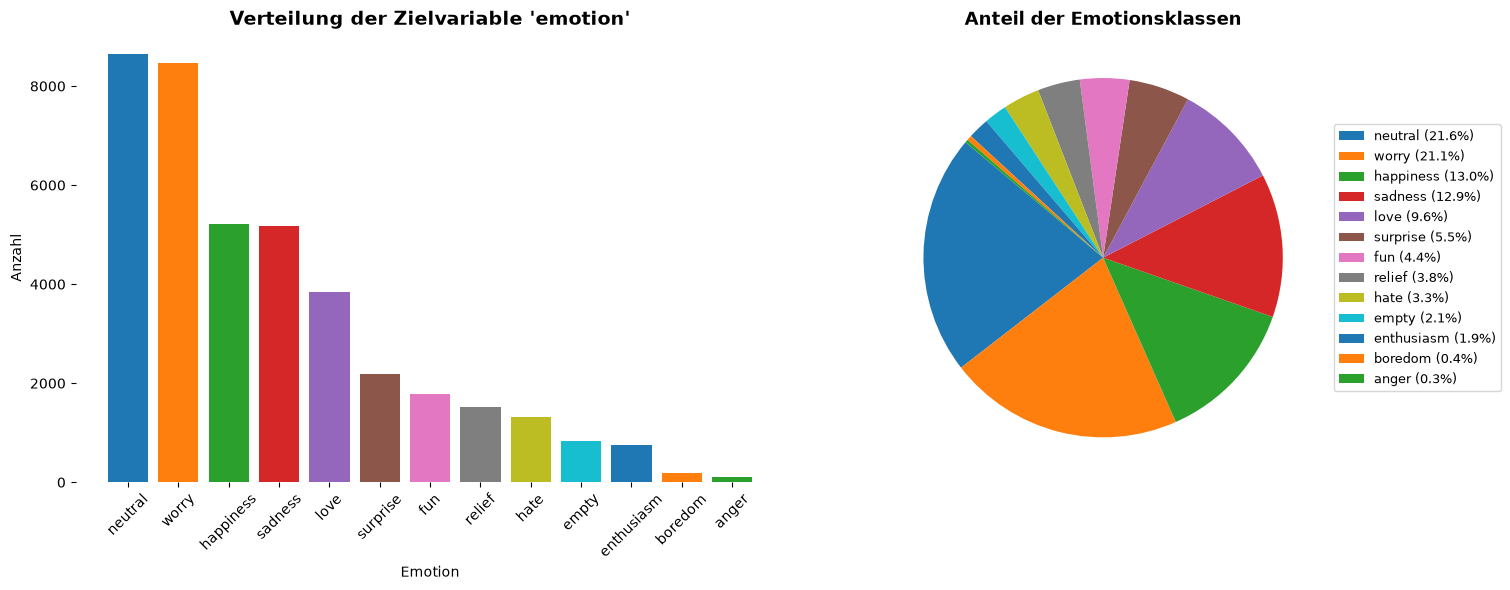

In [131]:
values = df["emotion"].value_counts()
labels = values.index
colors = plt.cm.tab10.colors

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

bars = ax_bar.bar(labels, values, color=colors[:len(labels)])
ax_bar.set_title("Verteilung der Zielvariable 'emotion'", fontsize=14, fontweight="bold")
ax_bar.set_xlabel("Emotion")
ax_bar.set_ylabel("Anzahl")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.spines[:].set_visible(False)

pct_labels = [f"{l} ({v/values.sum()*100:.1f}%)" for l, v in zip(labels, values)]
wedges, _ = ax_pie.pie(values, colors=colors[:len(labels)], startangle=140)
ax_pie.set_title("Anteil der Emotionsklassen", fontsize=13, fontweight="bold")
ax_pie.legend(wedges, pct_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()

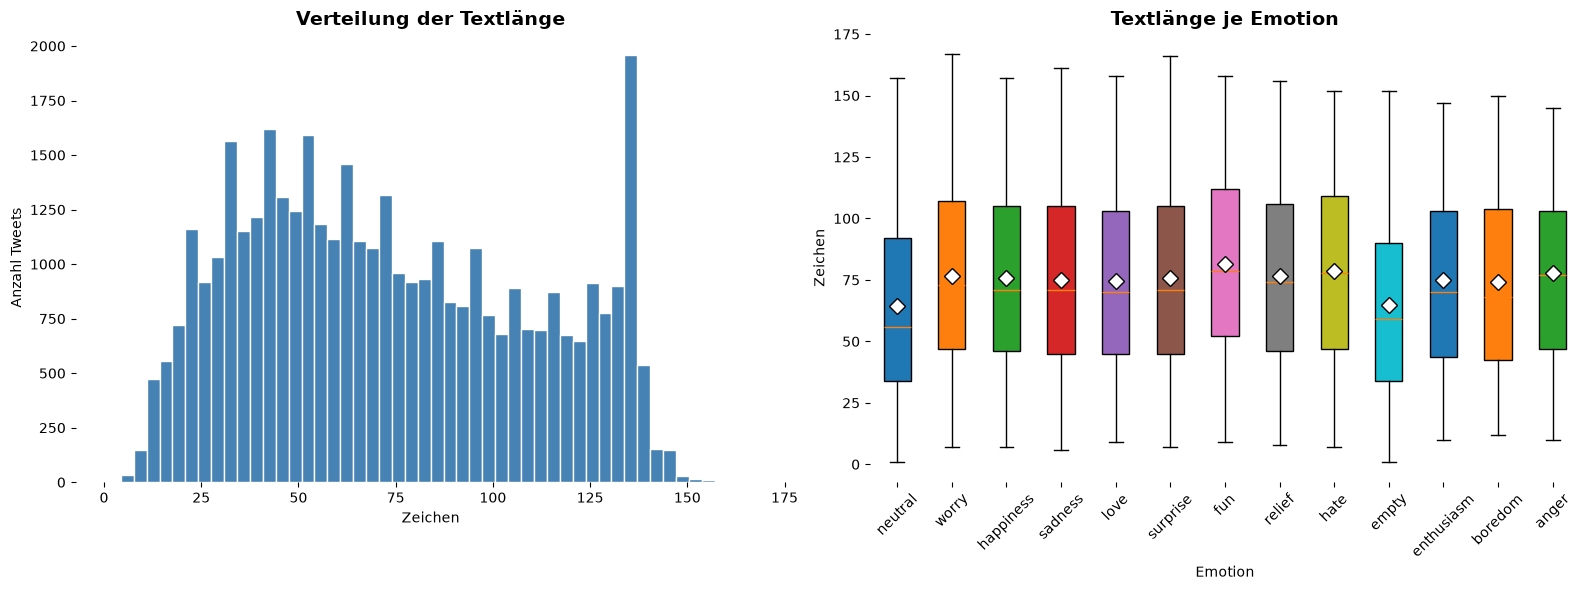

In [132]:
content_len = df.assign(text_length=df["content"].str.len())

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(16, 6))

ax_hist.hist(content_len["text_length"], bins=50, color="steelblue", edgecolor="white")
ax_hist.set_title("Verteilung der Textlänge", fontsize=14, fontweight="bold")
ax_hist.set_xlabel("Zeichen")
ax_hist.set_ylabel("Anzahl Tweets")
ax_hist.spines[:].set_visible(False)

data_per_emotion = [content_len[content_len["emotion"] == e]["text_length"].tolist() for e in labels]
bp = ax_box.boxplot(data_per_emotion, tick_labels=labels, patch_artist=True, showmeans=True, 
                    meanprops=dict(marker="D", markersize=8, markerfacecolor="white", markeredgecolor="black"))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
ax_box.set_title("Textlänge je Emotion", fontsize=14, fontweight="bold")
ax_box.set_xlabel("Emotion")
ax_box.set_ylabel("Zeichen")
ax_box.tick_params(axis="x", rotation=45)
ax_box.spines[:].set_visible(False)

plt.tight_layout()
plt.show()


- **Klassenungleichgewicht**: `neutral` (21,6 %) und `worry` (21,1 %) dominieren; `anger` hat nur 110 Einträge (0,3 %).
- Die **Textlänge** variiert kaum zwischen den Emotionsklassen und ist daher kein Merkmal der Emotion.
- Für das spätere Modell muss dieses Ungleichgewicht berücksichtigt

# 3.4. Data Preperation (Regex)

| Schritt | Regex-Pattern | Beschreibung |
|---------|---------------|--------------|
| Kleinschreibung | `.lower()` | Vereinheitlichung Groß-/Kleinschreibung |
| URLs entfernen | `https?://\S+\|www\.\S+` | HTTP/HTTPS-Links und www-Adressen |
| Mentions entfernen | `@\w+` | Twitter-Nutzernamen wie `@user` |
| Sonderzeichen entfernen | `[^\w\s]` | Punkte, Kommas, Ausrufezeichen etc. |
| Zahlen entfernen | `\d+` | Reine Ziffernfolgen |
| Leerzeichen normalisieren | `\s+` → `' '` | Mehrfache Leerzeichen auf eines reduzieren |

Normalisierung, Skalierung und Standardisierung ist für unseren Datensatz nicht relevant, da es sich um textuelle Daten handelt, welche im folgenden sowieso durch Tokenisierung, Vektorisierung etc. weiterverarbeitet werden müssen. Eine verzeitige Normalisierung ist daher nicht notwendig. Normalisierung im Sinne von Lemmatisierung könnte angewendet werden.

In [133]:
token = df.content.str.lower()                                        # Text in Kleinbuchstaben umwandeln
token = token.str.replace(r'https?://\S+|www\.\S+', '', regex=True)   # Hyperlinks entfernen
token = token.str.replace(r'@\w+', '', regex=True)                    # Nutzererwähnungen entfernen
token = token.str.replace(r'[^\w\s]', '', regex=True)                 # Sonderzeichen entfernen
token = token.str.replace(r'\d+', '', regex=True)                     # Ziffern/Zahlen entfernen
token = token.str.replace(r'\s+', ' ', regex=True).str.strip()        # Doppelte Leerzeichen entfernen
df["token"] = token

# 4.1. Datenqualität

In [134]:
df.describe()

,emotion,content,token
count,40000,40000,40000
unique,13,39827,38998
top,neutral,I just received a mothers day card from my lovely daughter wishing my a happy mothers day http://tr.im/kWK9,
freq,8638,14,99


## 4.1.1 Fehlende Werte

In [135]:
df.isna().sum()

emotion    0
content    0
token      0
dtype: int64

In [136]:
df.isnull().sum()

emotion    0
content    0
token      0
dtype: int64

Keine fehlende oder null Werte, die entfernt werden müssten...

In [137]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
 2   token    40000 non-null  str  
dtypes: str(3)
memory usage: 6.3 MB


,emotion,content,token
340,empty,0,
659,neutral,@Joshuah_Pearson,
664,neutral,@emlevins,
2621,surprise,@swpave ?????????????,
3181,neutral,@Clumsyflic,
...,...,...,...
38650,neutral,@Britt_Uh_Knee,
39206,neutral,@hmigroupllc,
39415,neutral,0,
39518,neutral,@Remy_Foster,


ABER: 99 Nachrichten sind durch den Regex filter leer geworden, und werden im Folgenden entfernt:

In [138]:
df = df[df.token != ""]        # Zeilen mit leeren token entfernen

In [139]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
Index: 39901 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39901 non-null  str  
 1   content  39901 non-null  str  
 2   token    39901 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,token


## 4.1.2 Duplikate

In [140]:
df[df.duplicated(subset="content", keep=False)]

,emotion,content,token
51,worry,why am i so tired?,why am i so tired
147,relief,I'm at work,im at work
324,sadness,I feel so deflated. No more doggy.,i feel so deflated no more doggy
366,worry,I feel so deflated. No more doggy.,i feel so deflated no more doggy
454,worry,Somebody please save the polar bears!,somebody please save the polar bears
...,...,...,...
39859,love,Happy Mothers Day,happy mothers day
39898,love,happy mothers day!,happy mothers day
39913,happiness,happy mother's day!,happy mothers day
39915,love,happy mother's day everyone,happy mothers day everyone


254 Nachrichten bzw. deren Tokenfolge sind Duplikate, welche im Folgenden entfernt werden:

In [141]:
df = df.drop_duplicates(subset="content", keep=False)    # Entfernen von Duplikaten

In [142]:
df.info()
df[df.content.duplicated(keep=False)]

<class 'pandas.DataFrame'>
Index: 39647 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39647 non-null  str  
 1   content  39647 non-null  str  
 2   token    39647 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,token


In [143]:
print(df.emotion.value_counts())
df.tail()

emotion
neutral       8514
worry         8416
happiness     5168
sadness       5139
love          3769
surprise      2175
fun           1774
relief        1516
hate          1322
empty          808
enthusiasm     757
boredom        179
anger          110
Name: count, dtype: int64


,emotion,content,token
39994,happiness,Succesfully following Tayla!!,succesfully following tayla
39996,love,Happy Mothers Day All my love,happy mothers day all my love
39997,love,"Happy Mother's Day to all the mommies out there, be you woman or man as long as you're 'momma' to someone this is your day!",happy mothers day to all the mommies out there be you woman or man as long as youre momma to someone this is your day
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEEP OUT MY NEW HIT SINGLES WWW.MYSPACE.COM/IPSOHOT I DEF. WAT U IN THE VIDEO!!,wassup beautiful follow me peep out my new hit singles i def wat u in the video
39999,love,@mopedronin bullet train from tokyo the gf and i have been visiting japan since thursday vacation/sightseeing gaijin godzilla,bullet train from tokyo the gf and i have been visiting japan since thursday vacationsightseeing gaijin godzilla


## 4.1.4 Weitere Qualitätsprobleme

Der Datensatz enthält 13 Emotionsklassen, die sehr ungleich verteilt sind. Die fünf häufigsten Klassen (neutral, worry, happiness, sadness, love) machen zusammen bereits rund 76 % aller Tweets aus (30.464 von 38.998), während die übrigen acht Klassen nur sehr selten vorkommen: `anger`⁠ z.B. mit nur 110 Einträgen (0,3 %).

So wenige Beispiele reichen nicht, damit ein Modell diese seltenen Emotionen zuverlässig lernen kann. Das starke Klassenungleichgewicht würde die Vorhersagequalität verschlechtern und die Ergebnisse verzerren. Durch die Fokussierung auf die **Top-5-Klassen** erhalten wir ein ausgewogeneres und besser lernbares Klassifikationsproblem, ohne den Großteil der Daten zu verlieren.

**Die Top-5-Klassen:**

1. `Neutral, n=8514`
2. `Worry, n=8416`
3. `Happiness, n=5168`
4. `Sadness, n=5139`
5. `Love, n=3769`

Da diese fünf Klassen jedoch weiterhin unterschiedlich häufig vertreten sind, wird gleichmäßig auf **n=3.769** Einträge pro Klasse gesampelt. Dieser Wert entspricht der Größe der kleinsten der fünf Klassen. So enthält jede Klasse gleich viele Trainingsbeispiele, was ein verzerrungsfreies Lernen ermöglicht.


In [235]:
results = {}        # Initialisierung einer leeren Liste für die trainierten Modelle

In [145]:
# Filten des Datensatz auf auf Top 5 Emotionsklassen
keep = ["neutral", "worry", "happiness", "sadness", "love"]     
df_filtered = df[df.emotion.isin(keep)]

In [146]:
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    df_filtered["content"], df_filtered["emotion"], test_size=0.15, random_state=42
)

baseline_vec = CountVectorizer()
X_raw_train_vec = baseline_vec.fit_transform(X_raw_train)
X_raw_val_vec = baseline_vec.transform(X_raw_val)

baseline_classifiers = [
    ("Baseline KNN", KNeighborsClassifier()),
    ("Baseline DTC", DecisionTreeClassifier(random_state=42)),
    # RF/MLP auf dem riesigen ungefilterten Rohtext-Vokabular sind auf CPU sehr teuer.
    # Fuer den schnellen Baseline-Vergleich (Vorverarbeitung ja/nein) reichen KNN+DTC.
    ("Baseline RFC", RandomForestClassifier(random_state=42)),
    ("Baseline MLP", MLPClassifier(random_state=42, early_stopping=True)),
]

for name, classifier in baseline_classifiers:
    classifier.fit(X_raw_train_vec, y_raw_train)
    y_pred = classifier.predict(X_raw_val_vec)
    f1 = f1_score(y_raw_val, y_pred, average="macro")
    print(f"{name}: F1-Score (val): {f1:.3f}")
    results[name] = (f1, classifier, X_raw_train_vec, X_raw_val_vec, None)

Baseline KNN: F1-Score (val): 0.286
Baseline DTC: F1-Score (val): 0.343
Baseline RFC: F1-Score (val): 0.387
Baseline MLP: F1-Score (val): 0.440


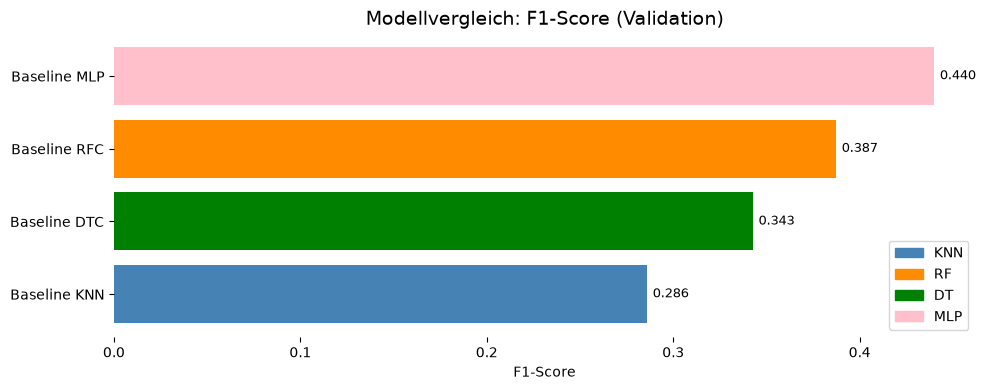

In [147]:
def plot_results(title="Modellvergleich: F1-Score (Validation)"):
    results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
    color_map = {"KNN": "steelblue", "RF": "darkorange", "DT": "green", "MLP": "pink"}
    colors = [next(c for k, c in color_map.items() if k in name) for name in results_df.index]

    _, ax = plt.subplots(figsize=(10, max(4, len(results_df) * 0.4)))
    bars = ax.barh(results_df.index, results_df.values, color=colors)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("F1-Score")
    ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
    ax.spines[:].set_visible(False)
    ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc="lower right")
    plt.tight_layout()
    plt.show()

plot_results()

In [148]:
# Sampeln der übrigen Emotionsklassen auf gleiche Verteilung mit jeweils n=3769 Tweets
df_filtered = df_filtered.groupby("emotion").sample(n=3769, random_state=42).reset_index(drop=True)

print(f"Verbleibende Klassen: {keep}")
print(f"Anteil am Gesamtdatensatz: {len(df_filtered) / 40000 * 100:.1f}%")
print(f"Verbleibende Einträge: {len(df_filtered)}")
print(f"Gelöschte Einträge: {len(df) - len(df_filtered)}")

df = df_filtered

Verbleibende Klassen: ['neutral', 'worry', 'happiness', 'sadness', 'love']
Anteil am Gesamtdatensatz: 47.1%
Verbleibende Einträge: 18845
Gelöschte Einträge: 20802


In [149]:
print(df.emotion.value_counts())

emotion
happiness    3769
love         3769
neutral      3769
sadness      3769
worry        3769
Name: count, dtype: int64


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18845 entries, 0 to 18844
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  18845 non-null  str  
 1   content  18845 non-null  str  
 2   token    18845 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


In [151]:
df.describe

<bound method NDFrame.describe of          emotion  \
0      happiness   
1      happiness   
2      happiness   
3      happiness   
4      happiness   
...          ...   
18840      worry   
18841      worry   
18842      worry   
18843      worry   
18844      worry   

                                                                                                                                        content  \
0      @R1CC1 that's funny...well, i'll say bye again b/c i'm really THAT delirious...lol... i worked 13 hrs i think...crazy...anyhoo bye lady!   
1                                                          @Sarah_LeAnn if it makes you feel better im studying on a sat night w/o blackberries   
2                                                                                                      @JessicaCorban stellar! You 2 look great   
3                                                                                                 mrskutcher &amp; aplusk you two are to 

# 5.1 Beschreibung des Korpus

Unser Korpus ist die Sammlung von Tweets in englischer Sprache. 

Die Tweets sind alle auf Englisch. Jeder Tweet ist ein eigener Eintrag mit einer zugeordneten Emotion. Nach der Bereinigung und der Beschränkung auf die fünf Klassen besteht unser Korpus aus 19.210 Tweets.

Der Text wird nachfolgend weiter optimiert: Stopwords wie „the", „and" oder „is" werden entfernt, Wörter auf ihren Wortstamm gekürzt (Lemmatisierung).

In [152]:
word_counts = df.token.str.split().explode().value_counts().reset_index()
word_counts.columns = ["word", "count"]

print("Word Instances: ", word_counts["count"].sum())
print("Word Types: ", len(word_counts))

Word Instances:  236268
Word Types:  20965


# 5.2. Wortfrequenzanalyse

Whitespace Tokenisierung

In [153]:
df["token"] = df["token"].str.split()     # Whitespace Tokenisierung eigener Spalte

In [154]:
df.tail()

,emotion,content,token
18840,worry,@DutchRaymond gay marriage isn't legal everywhere here.,"[gay, marriage, isnt, legal, everywhere, here]"
18841,worry,"has spent the last two weeks attempting to grow a beard (from scratch), but fears it may look a bit rubbish... http://twitpic.com/66tyb","[has, spent, the, last, two, weeks, attempting, to, grow, a, beard, from, scratch, but, fears, it, may, look, a, bit, rubbish]"
18842,worry,So lost on my owm tryinh to find matter in the o2,"[so, lost, on, my, owm, tryinh, to, find, matter, in, the, o]"
18843,worry,@fletcherxx maxxie and anwar. ep 5? i think. i am up to that one next.,"[maxxie, and, anwar, ep, i, think, i, am, up, to, that, one, next]"
18844,worry,"Whats your name: Adelaide-Marie How old r u: 14 Where Do u live: IN THE WORLD lol i jk, canada(toronto)","[whats, your, name, adelaidemarie, how, old, r, u, where, do, u, live, in, the, world, lol, i, jk, canadatoronto]"


## 5.2.3 Barchart Visualisierung

Anzahl Token (insgesamt):  236268
Anzahl einzigartiger Token |V|: 20965


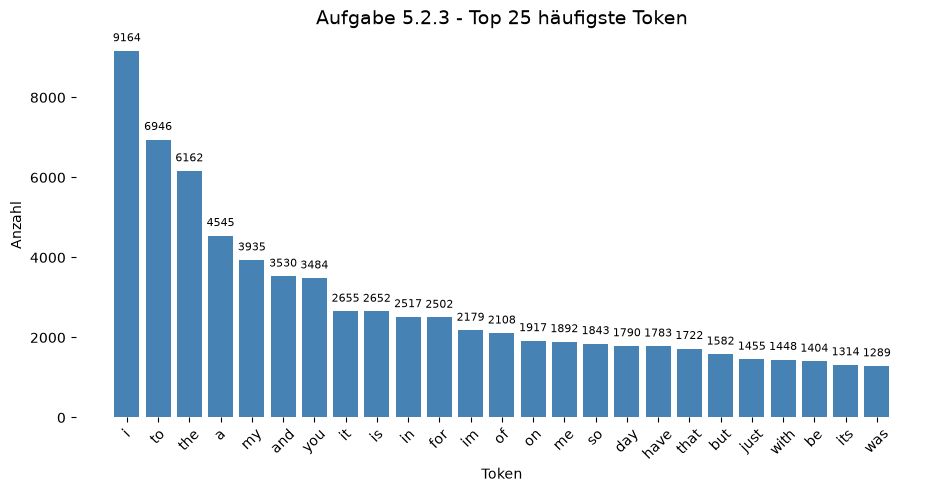

In [155]:
def plot_top_words(top_n=25):
    word_list = np.concatenate(df.token.values)

    word_counts = pd.Series(word_list).value_counts()
    word_counts = word_counts.reset_index()
    word_counts.columns = ["word", "count"]

    print("Anzahl Token (insgesamt): ", len(word_list))
    print("Anzahl einzigartiger Token |V|:", len(word_counts.word))

    top_words = word_counts.head(top_n)

    _, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(top_words["word"], top_words["count"], color="steelblue")
    ax.set_title(f"Aufgabe 5.2.3 - Top {top_n} häufigste Token", fontsize=14)
    ax.set_xlabel("Token")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[:].set_visible(False)
    _ = ax.bar_label(bars, padding=5, fontsize=8)
    plt.show()

plot_top_words()

Die Wortfrequenzanalyse zeigt, dass die häufigsten Wörter im Korpus wie „im", „day", „good" oder „go" haben keinen emotionalen oder inhaltlichen Mehrwert. Ihr hohes Aufkommen im gesamten Datensatz macht sie zu Stopwords, die im folgenden Schritt gefiltert werden sollten.

### 5.2.5 Stopwords entfernen

In [156]:
stop_words = set(stopwords.words("english"))
negation_stopwords = {"not", "no", "never", "nor"}
stop_words.difference_update(negation_stopwords)

print("Anzahl von Stopwords: " + str(len(stop_words)))
print("Stopwords: " + str(stop_words))

Anzahl von Stopwords: 195
Stopwords: {'me', 'which', 'before', "don't", 're', 'until', 'after', 'myself', 'about', 'hasn', "shouldn't", 'same', 'yourselves', 'between', 'it', 'out', 'of', 'this', "wasn't", "mightn't", 'so', 'in', 'd', 'am', 'through', 'into', 'own', 'or', 'more', 'above', "you're", 'shouldn', 'what', 'most', 'why', 'any', "i've", 'where', 'ourselves', "they'd", 'if', 'll', "we'd", "we'll", 'had', 's', 'a', 'at', 'my', 'your', 'wouldn', 'than', 'those', 'then', 'off', 'haven', 'm', "you've", 'its', 'wasn', 'having', 'up', 'was', 'isn', 'below', 'to', "we've", 'aren', 'for', 'needn', 'with', 'they', "he'd", "didn't", "he'll", 'are', 'should', 'couldn', 'she', 'we', 'but', 'his', "wouldn't", 'few', 'you', "weren't", "she'll", 'whom', "it'll", 'them', 've', 'didn', 'be', 'i', 'because', 'is', "should've", 'hers', 'our', "won't", 'hadn', 'very', 'who', "needn't", 'now', 'he', 'their', 'further', 'himself', 'that', "they're", 'o', 'doing', 'ain', "shan't", 'down', 'and', 'to

In [157]:
df.token = df.token.apply(lambda t: [w for w in t if w not in stop_words])  # Stopwords entfernen

Standard-Stopwords wurden erfolgreich entfernt. Es bleiben jedoch weiterhin Wörter, die gleichermaßen häufig in allen Klassen auftreten (z. B. „im", „day", „go"). Diese werden im nächsten Schritt durch eine iterative Schleife zusätzlich entfernt.

Anzahl Token (insgesamt):  138727
Anzahl einzigartiger Token |V|: 20829


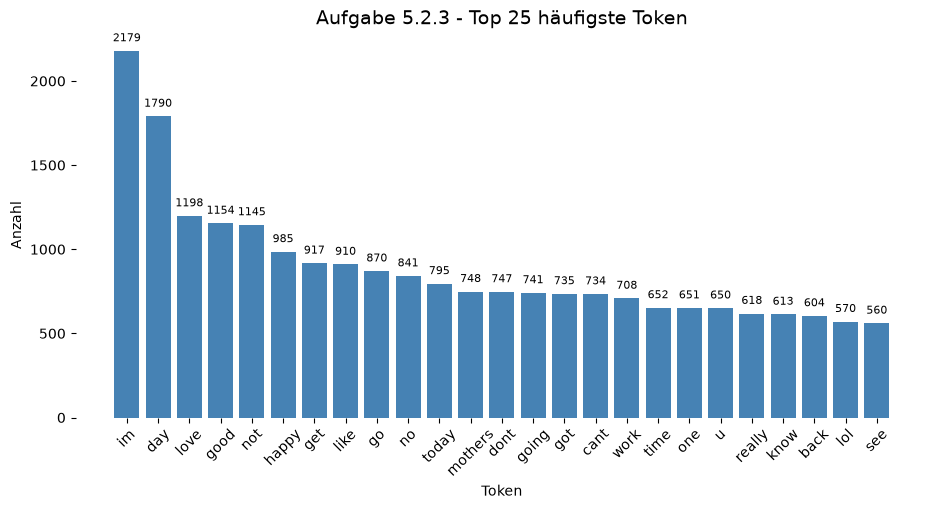

In [158]:
plot_top_words()

## 5.2.6 Byte Pair Encoding




Anzahl BPE-token (insgesamt): 188986
Anzahl einzigartiger BPE-token |V|: 4963

Beispiel:
  Original:   thats funnywell ill say bye bc im really deliriouslol worked hrs thinkcrazyanyhoo bye lady
  BPE-token: ['thats', 'funny', 'well', 'ill', 'say', 'bye', 'bc', 'im', 'really', 'deli', 'rious', 'lol', 'worked', 'hrs', 'think', 'crazy', 'any', 'hoo', 'bye', 'lady']


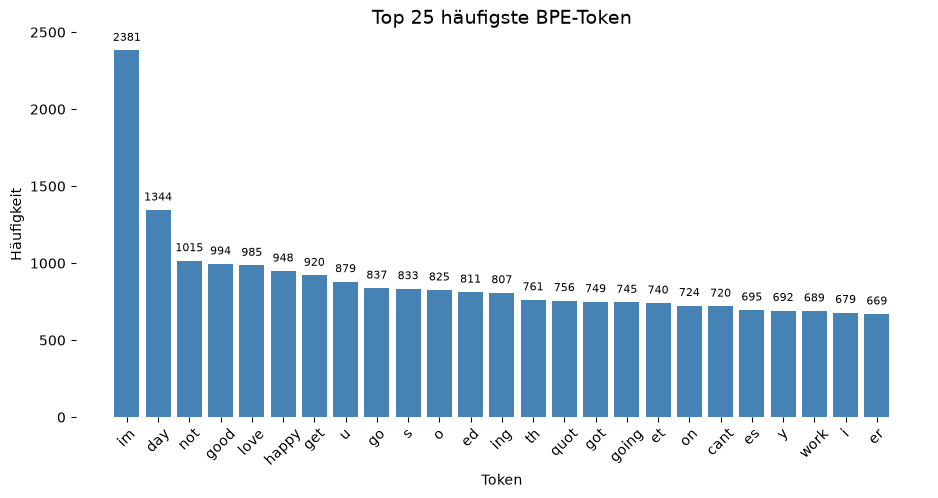

In [159]:
tokenizer = Tokenizer(BPE())
tokenizer.train_from_iterator(df.token.tolist(), BpeTrainer(vocab_size=5000))

bpe_corpus = df.token.apply(" ".join)

# Alle Tweets codieren und Häufigkeiten zählen
all_token = []
for sentence in bpe_corpus:
    all_token.extend(tokenizer.encode(sentence).tokens)

print(f"Anzahl BPE-token (insgesamt): {len(all_token)}")
print(f"Anzahl einzigartiger BPE-token |V|: {len(set(all_token))}")

# Beispiel
print(f"\nBeispiel:")
print(f"  Original:   {bpe_corpus.iloc[0]}")
print(f"  BPE-token: {tokenizer.encode(bpe_corpus.iloc[0]).tokens}")

# Barchart Top 25
top_n = 25
token_freq = pd.Series(all_token).value_counts()
top_token = token_freq.head(top_n)

_, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_token.index, top_token.values, color="steelblue")
ax.set_title(f"Top {top_n} häufigste BPE-Token", fontsize=14)
ax.set_xlabel("Token")
ax.set_ylabel("Häufigkeit")
ax.tick_params(axis="x", rotation=45)
ax.spines[:].set_visible(False)
_ = ax.bar_label(bars, padding=5, fontsize=8)
plt.show()

Byte Pair Encoding (BPE) arbeitet nicht auf Wortebene, sondern auf Zeichenebene. Es startet mit einzelnen Zeichen und fasst schrittweise die häufigsten Zeichenpaare zu Teilwörtern zusammen. 

Je nach konfigurierter Vocabulary Size sinkt die Anzahl der Word Types da seltene Wörter in wiederverwendbare Teilwörter zerlegt werden. Gleichzeitig steigt die Zahl der Word Instances, weil Wörter nun aus mehreren Teilwörtern bestehen können.

- **Niedrig** (z. B. 500): Die meisten Wörter werden in Einzelzeichen aufgeteilt.
- **Mittel** (z. B. 5000, siehe Barchart): Häufige Wörter bleiben erhalten, seltene werden in geteilt.
- **Hoch** (z. B. 28000, ca. ursprüngliches Vokabular): Fast alle Wörter bleiben ganz. Kaum Unterschied zur Whitespace Tokenisierung.

`s` wird zum am häufig auftretenden Token. Wörter mit Endung auf `s` (z. B. „feels", „says") werden als Stamm + `s` gespeichert.

Für unseren Anwendungsfall mit klassischen Machine Learning Klassifikatoren sowie Deep Learning, bietet BPE keinen Mehrwert. Die Zerlegung in Teilwörter reduziert die Aussagekraft der Features. BPE wird daher im weiteren Verlauf nicht verwendet.

## Lemmatisierung

In [160]:
lemmatizer = WordNetLemmatizer()
df["token"] = df.token.apply(lambda token: [lemmatizer.lemmatize(w) for w in token])

Anzahl Token (insgesamt):  138727
Anzahl einzigartiger Token |V|: 19336


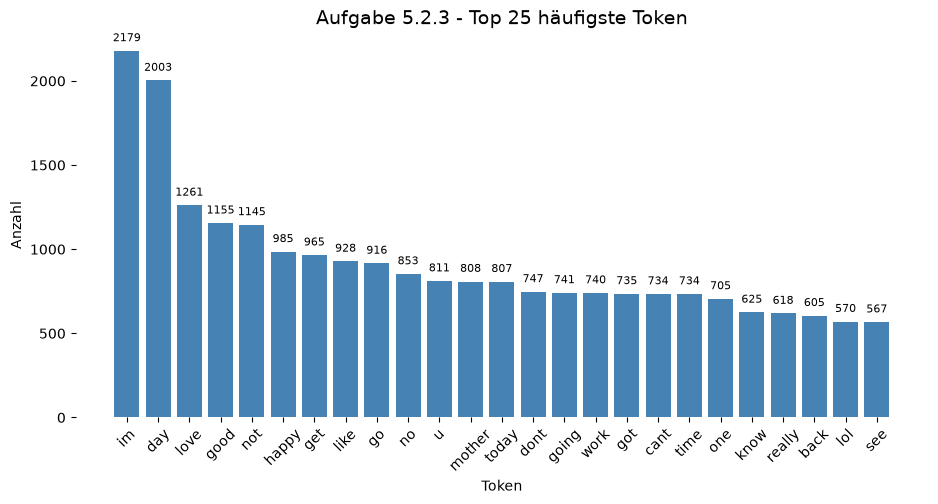

In [161]:
plot_top_words()

Lemmatisierung reduziert jedes Wort auf seine Grundform (Lemma) anhand eines Wörterbuchs: z. B. „running" → „run", „says" → „say", „happier" → „happy". Für die Lemmatisierung wurde eine Funktion der `nltk` Bibliothek gewählt. Durch die Lemmatisierung wird die Größe des Vokabular bzw. die Zahl der Word Types reduziert.

**Warum Lemmatisierung statt BPE?**

BPE zerlegt Wörter in Teilwörter und erzeugt damit Features wie `happ`, `iness` oder `s`. Lemmatisierung dagegen fasst bedeutungsgleiche Wortformen zusammen (`happy`, `happier`, `happiest` → `happy`) und reduziert so den Wortschatz ohne Informationsverlust.

# 5.3 Vektorisierung

Nach Datenaufbereitung kann der finale Datenkorpus definiert werden. Die zuvor durch Whitespace Tokenization erzeugte Tokenliste wird zur weiteren Verwendung in der Vektorisierung und Modellierung wieder in einen String umgewandelt.

In [162]:
corpus = df.token.apply(" ".join)
labels = df.emotion

## 5.3.1 Bag-of-Words (`CountVectorizer`)

In [163]:
bow_vectorizer = CountVectorizer()
corpus_bow = bow_vectorizer.fit_transform(corpus)

print("Anzahl der Features: " + str(bow_vectorizer.get_feature_names_out().shape[0]))
print(corpus_bow)

Anzahl der Features: 19312
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 133573 stored elements and shape (18845, 19312)>
  Coords	Values
  (0, 16628)	1
  (0, 6212)	1
  (0, 7931)	1
  (0, 14451)	1
  (0, 2374)	2
  (0, 1406)	1
  (0, 7954)	1
  (0, 13608)	1
  (0, 4152)	1
  (0, 18822)	1
  (0, 7728)	1
  (0, 16717)	1
  (0, 9034)	1
  (1, 7954)	1
  (1, 9902)	1
  (1, 5610)	1
  (1, 1610)	1
  (1, 15990)	1
  (1, 14431)	1
  (1, 11199)	1
  (1, 18722)	1
  (1, 1732)	1
  (2, 15835)	1
  (2, 9576)	1
  (2, 6786)	1
  :	:
  (18841, 14548)	1
  (18841, 1008)	1
  (18841, 14234)	1
  (18841, 1429)	1
  (18841, 5592)	1
  (18842, 9624)	1
  (18842, 10108)	1
  (18842, 5725)	1
  (18842, 11913)	1
  (18842, 17351)	1
  (18843, 11681)	1
  (18843, 16716)	1
  (18843, 11142)	1
  (18843, 5154)	1
  (18843, 10124)	1
  (18843, 712)	1
  (18844, 9524)	1
  (18844, 10969)	1
  (18844, 18501)	1
  (18844, 11632)	1
  (18844, 18844)	1
  (18844, 9450)	1
  (18844, 8524)	1
  (18844, 196)	1
  (18844, 2478)	1


## 5.3.2 TF-IDF Ansatz (`TfidfVectorizer`)

In [164]:
tfidf_vectorizer = TfidfVectorizer()
corpus_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("Anzahl der Features: " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))
print(corpus_tfidf)

Anzahl der Features: 19312
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 133573 stored elements and shape (18845, 19312)>
  Coords	Values
  (0, 16628)	0.17367076443869967
  (0, 6212)	0.35254714857794733
  (0, 7931)	0.174280088832234
  (0, 14451)	0.17875709306609278
  (0, 2374)	0.49529196254301916
  (0, 1406)	0.2584949413791494
  (0, 7954)	0.11211957549249214
  (0, 13608)	0.15592948424037112
  (0, 4152)	0.35254714857794733
  (0, 18822)	0.2648270783644287
  (0, 7728)	0.24764598127150958
  (0, 16717)	0.35254714857794733
  (0, 9034)	0.23272701253993816
  (1, 7954)	0.1703742492019718
  (1, 9902)	0.2545393849934506
  (1, 5610)	0.2525286352860437
  (1, 1610)	0.27343643788745087
  (1, 15990)	0.42277859510299814
  (1, 14431)	0.3877727148836513
  (1, 11199)	0.24517403676120722
  (1, 18722)	0.4369364404986099
  (1, 1732)	0.4330253332879356
  (2, 15835)	0.8105821089929902
  (2, 9576)	0.43508501796956345
  (2, 6786)	0.39199192812977784
  :	:
  (18841, 14548)	0.3303399035720782
  (18

Beide Vektorisierungen (Bag-of-Words und TF-IDF) wurden in gleich große Matrizen umgewandelt. Diese umfassen jeweils 18.845 Zeilen und 19.295 Spalten. Eine vollständige Matrix würde demnach über 360 Mio. Zellen enthalten. Das Sparse-Matrix-Format speichert jedoch nur die Werte ungleich 0, in diesem Fall 108408 Werte.

Auffällig ist der Unterschied im Zahlenformat. Während BoW ganzzahlige Integer speichert (z.B. 3, wenn ein Wort dreimal vorkommt), enthält TF-IDF Fließkommazahlen zwischen 0 und 1, abhängig von der gewichteten Häufigkeit pro Wort. Häufige Wörter, die in vielen Dokumenten vorkommen, erhalten dabei ein niedrigeres Gewicht, während seltenere aber charakteristische Wörter ein höheres Gewicht erhalten.

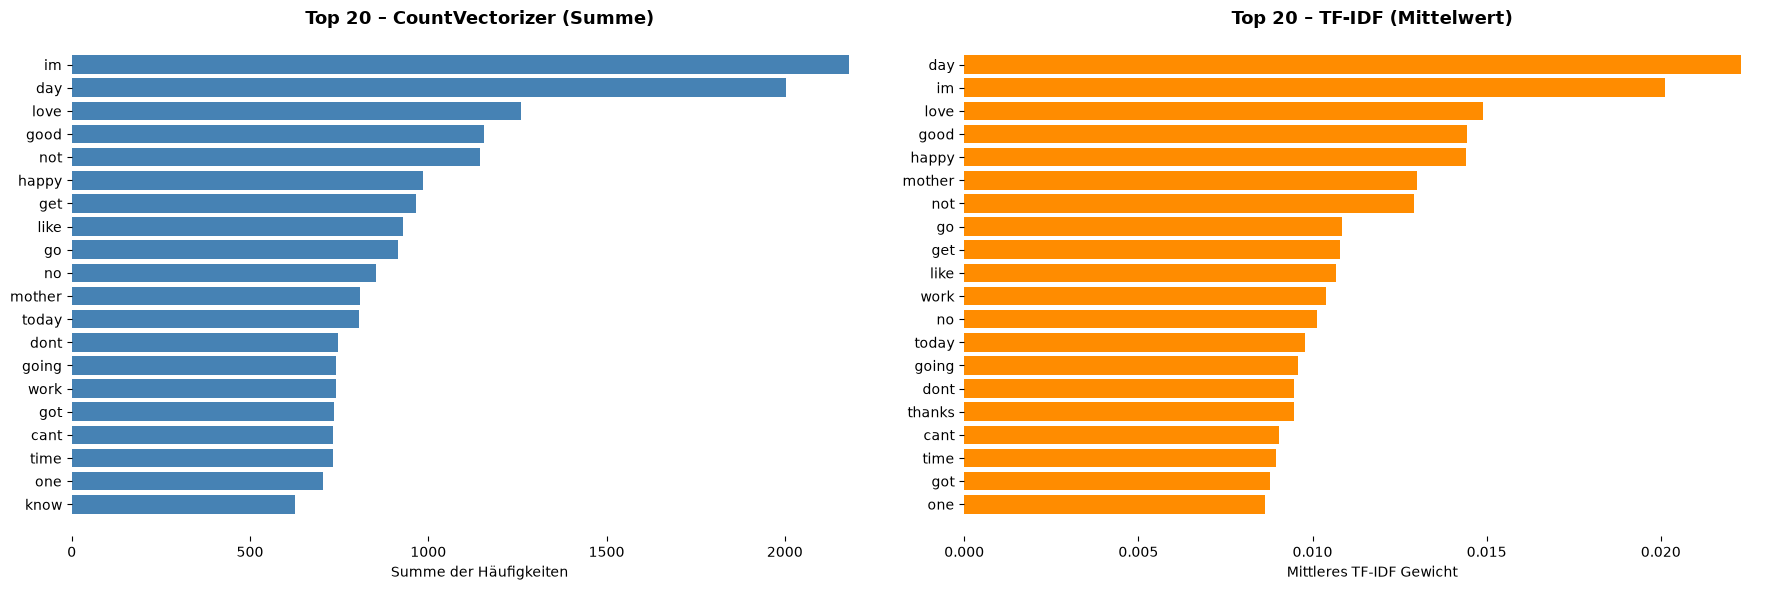

In [165]:
top_n = 20
feature_names = bow_vectorizer.get_feature_names_out()

# Top N by sum of counts
count_sums = np.asarray(corpus_bow.sum(axis=0)).flatten()
top_count_idx = count_sums.argsort()[::-1][:top_n]

# Top N by mean TF-IDF weight
tfidf_means = np.asarray(corpus_tfidf.mean(axis=0)).flatten()
top_tfidf_idx = tfidf_means.argsort()[::-1][:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.barh(feature_names[top_count_idx][::-1], count_sums[top_count_idx][::-1], color="steelblue")
ax1.set_title(f"Top {top_n} – CountVectorizer (Summe)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.spines[:].set_visible(False)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
ax2.barh(tfidf_feature_names[top_tfidf_idx][::-1], tfidf_means[top_tfidf_idx][::-1], color="darkorange")
ax2.set_title(f"Top {top_n} – TF-IDF (Mittelwert)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Mittleres TF-IDF Gewicht")
ax2.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

## 5.3.3 N-gram Ansatz

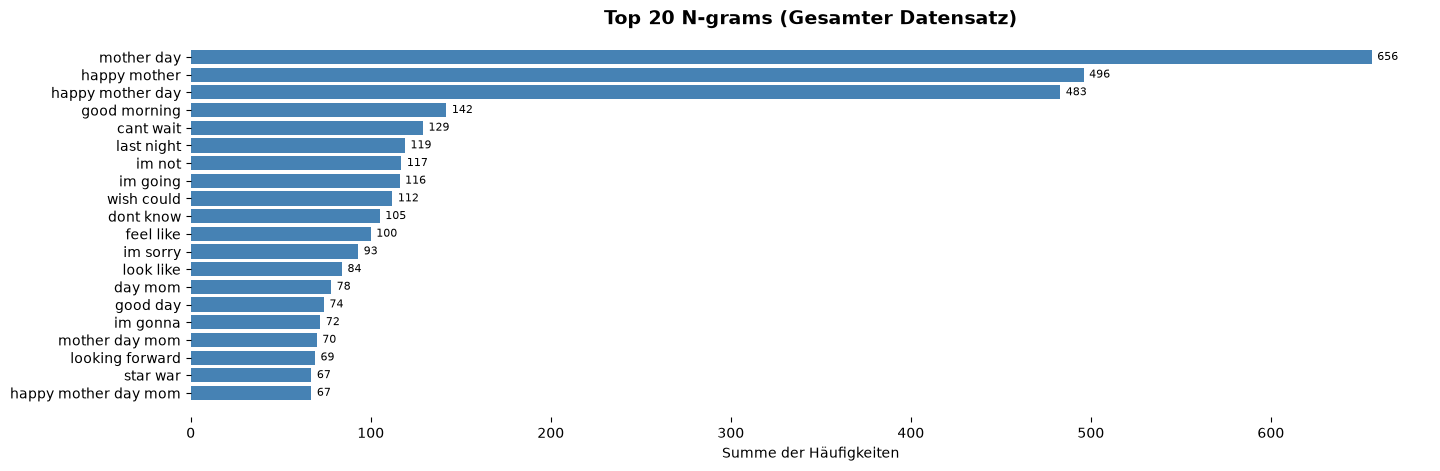

In [166]:
# N-gram Vektorisierung mit CountVectorizer
ngram_vectorizer = CountVectorizer(ngram_range=(2, 4))

# ngram_range gibt das untere und obere ende für n-grams an
#   ngram_range(1,1): nur Unigrams (default)
#   ngram_range(2,2): nur Bigrams
#   ngram_range(1,2): Unigrams und Bigrams

# Lernen des Vokabulars aus dem ganzen Korpus
X_ngram = ngram_vectorizer.fit_transform(corpus)                                 

# Bigram-Counts summieren
ngram_counts = X_ngram.sum(axis=0).A1

top_idx = ngram_counts.argsort()[::-1][:20]
top_features = ngram_vectorizer.get_feature_names_out()[top_idx]
top_values = ngram_counts[top_idx]

_, ax1 = plt.subplots(1, 1, figsize=(16, 5))

bars1 = ax1.barh(top_features[::-1], top_values[::-1], color="steelblue")
ax1.set_title("Top 20 N-grams (Gesamter Datensatz)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.bar_label(bars1, fmt="{:.0f}", padding=4, fontsize=8)
ax1.spines[:].set_visible(False)

plt.show()

Durch die N-grams werden häufige Wortzusammensetzungen sichtbar gemacht. Der Datensatz enthält häufige n-gram Kombinatationen, die in mehrere Emotionklassen vertreten (siehe Grafik unten z.B. "mother day") und daher nicht trennscharf einer Emotion zuordbar. Woher kommt das? Nach manueller Sichtung der Tweet csv-Datei, zeigte sich dass im Zeitraum der Datenerhebung der Muttertag stattgefunden hat und viele Tweets (>700) diesen thematisieren. Die lässt sich auch gut an an den beiden Vektorisierungen ohne N-grams erkennen, da "happy", "mother" und "day" zu den häufigsten Token gehören.

Zu lange n-grams könnten Overfitting an den Trainingssatz begünstigen und die Generalisierbarkeit auf andere fremde Datensätze einschränken. Wir fokussieren uns hier daher auf pimär auf Unigramme (n=1) mit optionaler Berücksichtigung von Bigrammen (n=2) und Trigrammen (n=3).

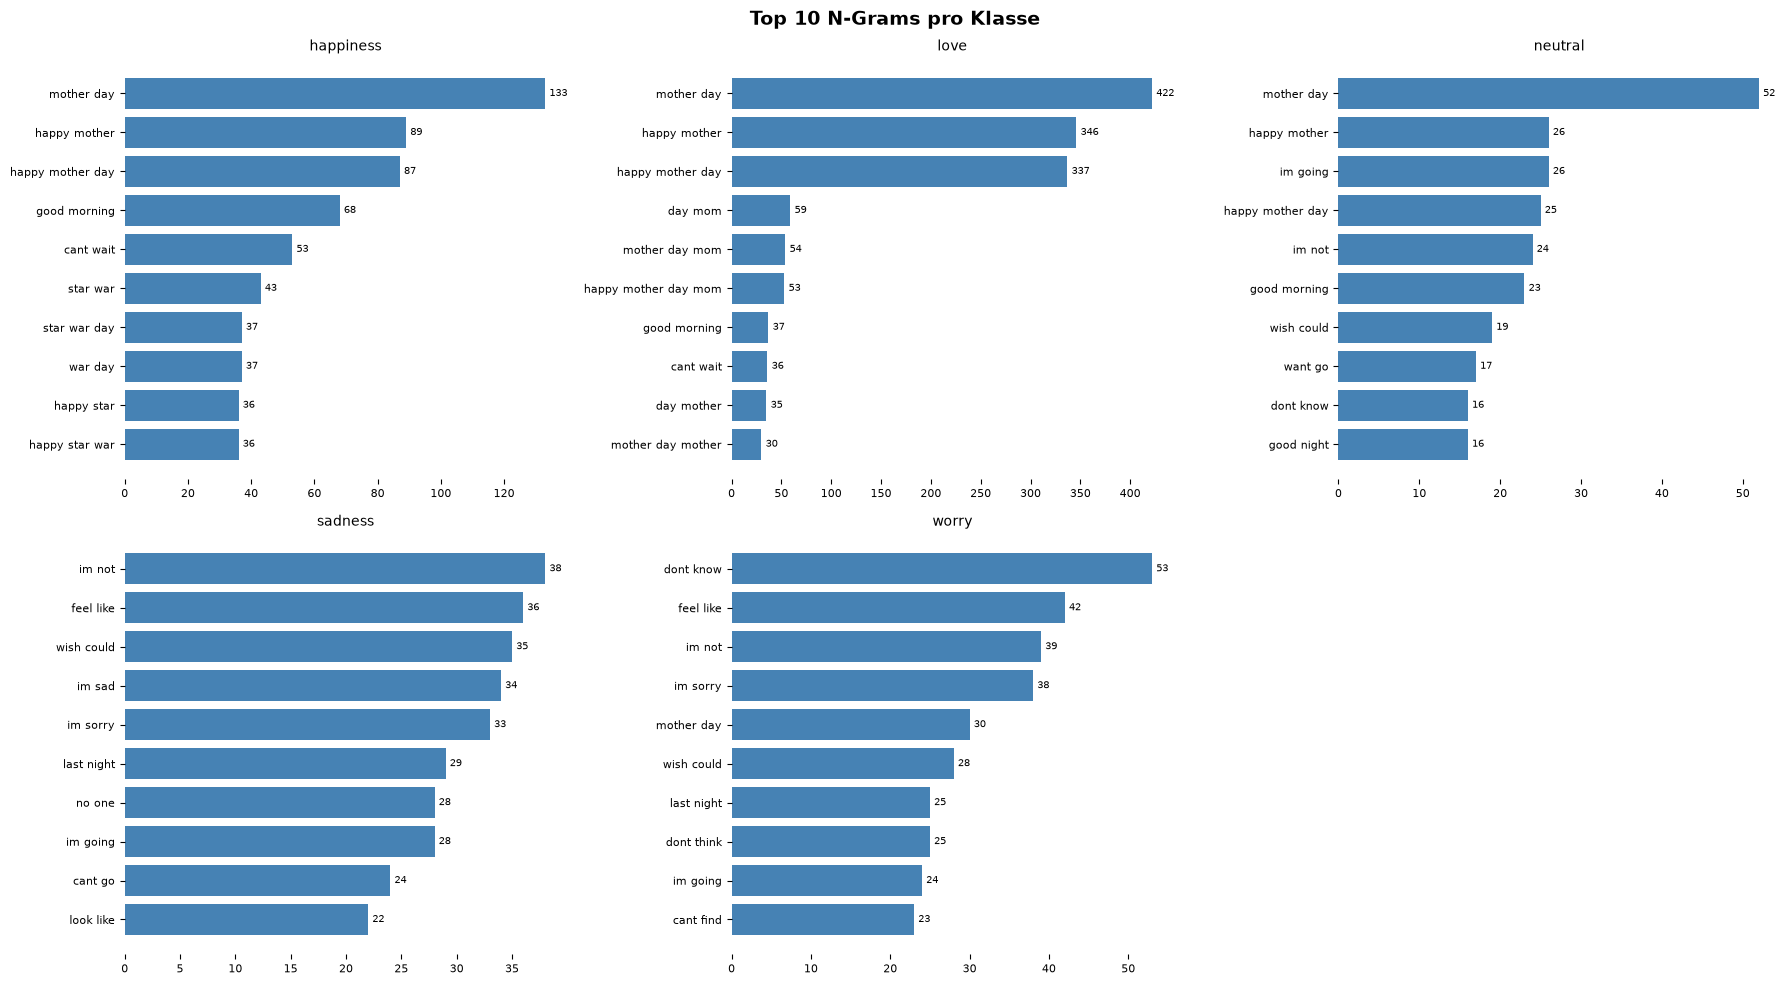

In [167]:
classes = sorted(labels.unique())
ngram_names = ngram_vectorizer.get_feature_names_out()
y_train_arr = labels.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Top 10 N-Grams pro Klasse", fontsize=14, fontweight="bold")

for row, cls in enumerate(classes):
    mask = y_train_arr == cls

    cls_count = np.asarray(X_ngram[mask].sum(axis=0)).flatten()
    top_idx = cls_count.argsort()[::-1][:10]
    ax = axes[row]
    bars = ax.barh(ngram_names[top_idx][::-1], cls_count[top_idx][::-1], color="steelblue")
    ax.set_title(f"{cls}", fontsize=10)
    ax.bar_label(bars, fmt="{:.0f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [168]:
# Mean count per class for every n-gram
class_scores = np.vstack([
    np.asarray(X_ngram[y_train_arr == cls].mean(axis=0)).flatten()
    for cls in classes
])  # shape: (n_classes, n_features)

# Only keep n-grams that appear in exactly one class
exclusive_mask = (class_scores > 0).sum(axis=0) == 1

unique_ngrams = {}
for i, cls in enumerate(classes):
    class_exclusive = exclusive_mask & (class_scores[i] > 0)
    candidate_idx = np.where(class_exclusive)[0]
    top_idx = candidate_idx[class_scores[i][candidate_idx].argsort()[::-1][:10]]
    unique_ngrams[cls] = ngram_names[top_idx].tolist()

pd.DataFrame(unique_ngrams)

,happiness,love,neutral,sadness,worry
0,fun fun,mom love,frenchiebday frenchiebday,kinda sad,whole body
1,happy juddday,love love love,frenchiebday frenchiebday frenchiebday,low low,school next
2,time ever,love boy,frenchiebday frenchiebday frenchiebday frenchiebday,made sad,getting worse
3,thanks everyone,day mom love,time like,low low low,not swine
4,night last,love em,work work,low low low low,thats going
5,show amazing,love one,bed night,back hurt,hope didnt
6,thank thank,youre best,fellow tweeter,im gonna cry,quite like
7,fun fun fun,mother day mom love,card card,life suck,going way
8,long day work,im loving,time going,really missing,not feeling good
9,everyone nice,wishing mother,week not,sad time,couple week ago


# 6.1 Machine Learning

**Inputvariablen:** Als Eingabe für die Modelle verwenden wir verschiedene Vektorrepräsentationen unseres der Trainingskorpera. Konkret vergleichen wir Bag-of-Words (mit dem CountVectorizer) und TF-IDF. Jeder Tweet wird dabei als Vektor repräsentiert, dessen Dimensionen den Häufigkeiten bzw. Gewichtungen der enthaltenen token entsprechen.

**Outputvariablen:** Die Zielvariable ist die Emotionskategorie eines Tweets. Das Modell ordnet jedem Eingabevektor eine dieser Klassen zu. Die Güte der Vorhersage wird anschließend anhand der Testdaten mit dem F1-Score gemessen, der Präzision und Recall über alle Klassen gleichgewichtig berücksichtigt.

## 6.2 Prediction vs. Inference

+ **Prediction:**  Unser Ziel ist die möglichst genaue Vorhersage (Prediction) der Emotion, nicht die Erklärung kausaler Zusammenhänge zwischen Features und Label wie bei Inference gefordert.

+ **Inference:**
Eine Frage wäre daher welche Inputvariable (Wörter) ein Indikator für eine spezifische Emotion ist und zu welcher Warscheinlichkeit. Die Wortfrequezanalyse 

## 6.3 Classification vs. Regression

Im vorliegenden Anwendungsfall handelt es sich um eine Klassifikation, da die Zielvariablen aus Klassen besteht und keine kontinuierliche Werte vorhergesagt werden.


# 7.1 Training und Test von Modellen

## 7.1.1 Trainings-, Validierungs- und Testdaten

In [169]:
# Split: 70% Train / 15% Validation / 15% Test
X_train, X_test, y_train, y_test = train_test_split(corpus, labels, test_size=0.15, random_state=42)

# 0.176 ≈ 15/85, sodass Validation und Test gleich groß
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.176, random_state=42)

In [170]:
total = len(X_train) + len(X_val) + len(X_test)

print(f"Train      ({len(X_train)/total*100:.0f}%) : {len(X_train)}")
print(f"Validation ({len(X_val)/total*100:.0f}%) : {len(X_val)}")
print(f"Test       ({len(X_test)/total*100:.0f}%) : {len(X_test)}")

Train      (70%) : 13198
Validation (15%) : 2820
Test       (15%) : 2827


In [171]:
print(X_train)

15294                    ohhh got think miss piston really hope joe cook something big
8922                                                                       playing uno
11292                                                         look like schuhz arabyrd
17993                                                      ugh know economy depressing
3258                                                  quotleave piecesquot wrecker hmm
                                             ...                                      
11738              fuck cant feel like cry bit realy dont want bothering sooooooo much
3751     twitter useful reminds people forgot ask given day also excellent inspiration
11560                                           waiting aaron get town leave work booo
16482              laptop broke want help girl take best buy weekend please ill feed u
15345                                                                 happened winston
Name: token, Length: 13198, dtype: str


In [172]:
print(y_test)

17138        worry
423      happiness
11434      sadness
14783      sadness
5216          love
           ...    
11438      sadness
9676       neutral
10423      neutral
13523      sadness
6759          love
Name: emotion, Length: 2827, dtype: str


`min_df=5`: Ein Token muss in mindestens 5 Dokumenten vorkommen, um ins Vokabular aufgenommen zu werden. Filtert seltene Wörter und, die nicht generalisieren.

`max_df=0.8`: Ein Token, das in mehr als 80% aller Dokumente vorkommt, wird ignoriert. Das entfernt sehr häufige Wörter (ähnlich wie Stoppwörter), die keine Unterscheidungskraft zwischen den Emotionsklassen haben. Diese Vorgehensweise ist ähnlich zu der erweiterten Stopword-Entfernung wie in 5.2.1 dokumentiert. Der Unterschied liegt jedoch im Fokus auf 80% der Dokumente (Tweets) statt auf die Klassen.

In [173]:
bow_vectorizer = CountVectorizer(min_df=5, max_df=0.8)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

features_bow = (X_train_bow, X_val_bow, X_test_bow)

print("Anzahl der Spalten (Feature): " + str(bow_vectorizer.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 2299


In [174]:
count_vectorizer_ngram = CountVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.8)

X_train_bow_ngram = count_vectorizer_ngram.fit_transform(X_train)
X_val_bow_ngram = count_vectorizer_ngram.transform(X_val)
X_test_bow_ngram = count_vectorizer_ngram.transform(X_test)

features_bow_ngram = (X_train_bow_ngram, X_val_bow_ngram, X_test_bow_ngram)

print("Anzahl der Spalten (Feature): " + str(count_vectorizer_ngram.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 3281


In [175]:
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

features_tfidf = (X_train_tfidf, X_val_tfidf, X_test_tfidf)

print("Anzahl der Spalten (Feature): " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 2299


In [176]:
tfidf_vectorizer_ngram = TfidfVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.8)

X_train_tfidf_ngram = tfidf_vectorizer_ngram.fit_transform(X_train)
X_val_tfidf_ngram = tfidf_vectorizer_ngram.transform(X_val)
X_test_tfidf_ngram = tfidf_vectorizer_ngram.transform(X_test)

features_tfidf_ngram = (X_train_tfidf_ngram, X_val_tfidf_ngram, X_test_tfidf_ngram)

print("Anzahl der Spalten (Feature): " + str(tfidf_vectorizer_ngram.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 3281


Erkennbar ist, dass durch die strikte Limitierung mit `min_df` und `max_df`, die Anzahl der Features stark reduziert wird. Von zuvor bis zu 20.000 Features wird das Vokabular auf zwischen 2299 (ohne Ngrams) und 3281 (mit Ngrams) reduziert. Dies stellt bereits eine starke Reduktion dar, sodass im folgenden mit dieser statischen Feature-Zahl fortgefahren wird. Von einer weiteren Optimierung der `max_features` im folgenden abgesehen. Das Hyperparametertuning ist daher strikt auf Modellparameter fokussiert, welche mit den gesamten Features trainiert werden.

## 7.1.2 Training

In [177]:
def tune_hyperparameter(classifier, param_grid, features, name=None, save_best_model=False):
    X_train, X_val, X_test = features

    gs = GridSearchCV(classifier, param_grid=param_grid, cv=3, scoring="f1_macro")
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_pred_val = best_model.predict(X_val)
    y_pred_train = best_model.predict(X_train)

    f1_validation = f1_score(y_val, y_pred_val, average="macro")
    f1_training = f1_score(y_train, y_pred_train, average="macro")

    print(f"Best params: {gs.best_params_}  |  Best score: {gs.best_score_:.3f}\n")
    
    print(f"F1-Score (validation): {f1_validation:.3f}")
    print(f"F1-Score (training):   {f1_training:.3f}\n")

    if save_best_model:
        # Klassifikationsreport erzeugen
        print(f"=== {name} ===\n{classification_report(y_val, y_pred_val, zero_division=0)}")
        results[name] = (f1_validation, best_model, X_train, X_val, X_test)

    # return (gs.best_params_, gs.best_estimator_)
    return

### K Nearest Neighbor

Hier wird untersucht welche Vektorisierung in Verbindung mit KNN das beste F1 Scoring ergibt.

In [178]:
knn_classifier = KNeighborsClassifier()

#### Hyperparametertuning: KNN mit BoW Vektorisierung

In [179]:
parameter = {
    "n_neighbors": [3, 5, 8, 11, 15, 16, 18, 20]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=knn_classifier, param_grid=parameter, features=features_bow)

Best params: {'n_neighbors': 5}  |  Best score: 0.289

F1-Score (validation): 0.306
F1-Score (training):   0.497



Optimum KNN mit BoW liegt vermutlich bei k=5.

In [ ]:
parameter = {
    "n_neighbors": [1, 4, 5, 6]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="KNN: BoW",
    save_best_model=True
)

Best params: {'n_neighbors': 4}  |  Best score: 0.293

F1-Score (validation): 0.300
F1-Score (training):   0.532

=== KNN: BoW ===
              precision    recall  f1-score   support

   happiness       0.28      0.32      0.30       564
        love       0.44      0.39      0.42       580
     neutral       0.26      0.52      0.35       575
     sadness       0.40      0.22      0.29       550
       worry       0.28      0.10      0.15       551

    accuracy                           0.32      2820
   macro avg       0.33      0.31      0.30      2820
weighted avg       0.33      0.32      0.30      2820



#### Hyperparametertuning: KNN mit BoW Vektorisierung und N-gram

In [181]:
parameter = {
    "n_neighbors": [3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_bow_ngram)

Best params: {'n_neighbors': 5}  |  Best score: 0.292

F1-Score (validation): 0.301
F1-Score (training):   0.497



Optimum KNN mit BoW und Ngrams liegt vermutlich bei k=8.

In [182]:
parameter = {
    "n_neighbors": [6, 7, 8, 9, 10]
}

# Zweiter GridSearch
tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_bow_ngram,
    name="KNN: BoW + Ngram",
    save_best_model=True
)

Best params: {'n_neighbors': 7}  |  Best score: 0.288

F1-Score (validation): 0.302
F1-Score (training):   0.452

=== KNN: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.30      0.31      0.31       564
        love       0.47      0.42      0.44       580
     neutral       0.26      0.60      0.36       575
     sadness       0.42      0.19      0.26       550
       worry       0.34      0.08      0.13       551

    accuracy                           0.32      2820
   macro avg       0.36      0.32      0.30      2820
weighted avg       0.36      0.32      0.30      2820



#### Hyperparametertuning: KNN mit TF-IDF Vektorisierung

In [183]:
parameter = {
    "n_neighbors": [1, 3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_tfidf)

Best params: {'n_neighbors': 5}  |  Best score: 0.234

F1-Score (validation): 0.251
F1-Score (training):   0.458



Optimum KNN mit TF-IDF liegt vermutlich bei k=1.

In [ ]:
parameter = {
    "n_neighbors": [1, 2, 4]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_tfidf,
    name="KNN: TF-IDF",
    save_best_model=True
)

Best params: {'n_neighbors': 4}  |  Best score: 0.240

F1-Score (validation): 0.264
F1-Score (training):   0.496

=== KNN: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.27      0.33      0.30       564
        love       0.38      0.29      0.33       580
     neutral       0.24      0.49      0.32       575
     sadness       0.34      0.15      0.21       550
       worry       0.25      0.12      0.16       551

    accuracy                           0.28      2820
   macro avg       0.30      0.28      0.26      2820
weighted avg       0.30      0.28      0.27      2820



#### Hyperparametertuning: KNN mit TF-IDF Vektorisierung und N-gram

In [185]:
parameter = {
    "n_neighbors": [3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_tfidf_ngram)

Best params: {'n_neighbors': 5}  |  Best score: 0.222

F1-Score (validation): 0.254
F1-Score (training):   0.464



Optimum KNN mit TF-IDF und Ngrams liegt vermutlich bei k=1.

In [ ]:
parameter = {
    "n_neighbors": [1, 4, 6]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_tfidf_ngram,
    name="KNN: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'n_neighbors': 1}  |  Best score: 0.243

F1-Score (validation): 0.253
F1-Score (training):   0.962

=== KNN: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.21      0.56      0.31       564
        love       0.41      0.24      0.30       580
     neutral       0.28      0.21      0.24       575
     sadness       0.36      0.18      0.24       550
       worry       0.27      0.13      0.18       551

    accuracy                           0.27      2820
   macro avg       0.30      0.26      0.25      2820
weighted avg       0.30      0.27      0.25      2820



### Decision Tree

Hier wird untersucht welche Vektorisierung in Verbindung mit DTC das beste F1 Scoring ergibt.

In [187]:
dtc_classifier = DecisionTreeClassifier(random_state=42)

#### Hyperparametertuning: DTC mit BoW Vektorisierung

In [188]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
dtc_1 = DecisionTreeClassifier(random_state=42)
dtc_1.fit(X_train_bow, y_train)

print(f"Tiefe: {str(dtc_1.get_depth())}")
print(f"Blätter: {str(dtc_1.get_n_leaves())}\n")

# Vorhersagen & Bewertung
dt_train_predict = dtc_1.predict(X_train_bow)
dt_test_predict = dtc_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

# path = dt_classifier.cost_complexity_pruning_path(X_count_train, y_train)
# print(len(path["ccp_alphas"]))

Tiefe: 907
Blätter: 8200

F1-Score (Validation): 0.354
F1-Train (Train): 0.969


Der Baum ist bereits relativ groß (Viele Blätter und hohe Tief). Dies lässt auf starkes Overfitting schließen, was durch den großen Unterschied zwischen den F1-Scores für Train und Test nur verdeutlicht wird. Um das Overfitting zu verhindern, sollte die größe des Baums eingeschränkt werden.

Der Parameter `min_samples_leaf` legt fest, wie viele Samples ein Blatt mindestens umfassen muss. Dieser Parameter beschränkt implizit auch die maximale Tiefe des Baums. Ziel ist das Overfitting durch Abbildung einzelner Samples auf einzelne Blätter zu reduzieren. Im folgenden wird ein weiterer Test durchgeführt mit Beschränkung der Mindestanzahl auf 10 Samples pro Blatt. 

In [ ]:
# Zweiter einfacher Decision Tree als Anhaltspunkt für Parameter
dtc_2 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
dtc_2.fit(X_train_bow, y_train)

print(f"Tiefe: {str(dtc_2.get_depth())}")
print(f"Blätter: {str(dtc_2.get_n_leaves())} \n")

# Vorhersagen & Bewertung
dt_train_predict = dtc_2.predict(X_train_bow)
dt_test_predict = dtc_2.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}") 

# path = dt_classifier.cost_complexity_pruning_path(X_count_train, y_train)
# print(len(path["ccp_alphas"]))

Tiefe: 192
Blätter: 448 

F1-Score (Validation): 0.421
F1-Train (Train): 0.461


Der zweite Test-Baum mit min_samples_leaf zeigt sowohl einen deutlich höheren F1-Score im Test auf, als auch stark verringertes Overfitting. Dies unterstreicht die Notwendigkeit von Hyperparametertuning.

In [190]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 11}  |  Best score: 0.396

F1-Score (validation): 0.413
F1-Score (training):   0.449



Optimum DT mit BoW liegt vermutlich bei
+ min_sample_leaf=11
+ ccp_alpha=0.0001

In [ ]:
parameter = {
    "min_samples_leaf": [1, 8, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="DTC: BoW",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.395

F1-Score (validation): 0.413
F1-Score (training):   0.431

=== DTC: BoW ===
              precision    recall  f1-score   support

   happiness       0.43      0.42      0.43       564
        love       0.61      0.45      0.52       580
     neutral       0.36      0.48      0.41       575
     sadness       0.41      0.35      0.38       550
       worry       0.32      0.35      0.33       551

    accuracy                           0.41      2820
   macro avg       0.43      0.41      0.41      2820
weighted avg       0.43      0.41      0.41      2820



Optimum doch nicht bei min_sample_leaf=11 sonder bei min_sample_leaf=20.

#### Hyperparametertuning: DTC mit BoW Vektorisierung und Ngrams

In [192]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 11}  |  Best score: 0.396

F1-Score (validation): 0.412
F1-Score (training):   0.450



In [ ]:
parameter = {
    "min_samples_leaf": [1, 8, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_bow_ngram,
    name="DTC: BoW + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.395

F1-Score (validation): 0.411
F1-Score (training):   0.430

=== DTC: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.43      0.41      0.42       564
        love       0.61      0.45      0.52       580
     neutral       0.36      0.53      0.43       575
     sadness       0.42      0.31      0.36       550
       worry       0.32      0.35      0.34       551

    accuracy                           0.41      2820
   macro avg       0.43      0.41      0.41      2820
weighted avg       0.43      0.41      0.41      2820



#### Hyperparametertuning: DTC mit TF-IDF Vektorisierung

In [194]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 12}  |  Best score: 0.370

F1-Score (validation): 0.393
F1-Score (training):   0.489



In [ ]:
parameter = {
    "min_samples_leaf": [1, 7, 9, 13, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

# Zweiter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_tfidf,
    name="DTC: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.379

F1-Score (validation): 0.404
F1-Score (training):   0.457

=== DTC: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.41      0.44      0.42       564
        love       0.59      0.47      0.52       580
     neutral       0.37      0.52      0.43       575
     sadness       0.39      0.33      0.36       550
       worry       0.32      0.27      0.29       551

    accuracy                           0.41      2820
   macro avg       0.41      0.41      0.40      2820
weighted avg       0.41      0.41      0.41      2820



#### Hyperparametertuning: DTC mit TF-IDF Vektorisierung und Ngrams

In [196]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 12}  |  Best score: 0.377

F1-Score (validation): 0.376
F1-Score (training):   0.491



In [ ]:
parameter = {
    "min_samples_leaf": [1, 7, 9, 13, 20, 100],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Zweiter GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.380

F1-Score (validation): 0.392
F1-Score (training):   0.461



In [ ]:
parameter = {
    "min_samples_leaf": [18, 19, 20, 21, 22],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Dritter GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.380

F1-Score (validation): 0.392
F1-Score (training):   0.461



In [ ]:
parameter = {
    "min_samples_leaf": [1, 10, 19, 20, 21],
    "ccp_alpha": [0, 0.0001, 0.001]
}

# Vierter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_tfidf_ngram,
    name="DTC: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  Best score: 0.380

F1-Score (validation): 0.392
F1-Score (training):   0.461

=== DTC: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.40      0.38      0.39       564
        love       0.53      0.46      0.50       580
     neutral       0.34      0.47      0.40       575
     sadness       0.41      0.38      0.39       550
       worry       0.32      0.27      0.29       551

    accuracy                           0.39      2820
   macro avg       0.40      0.39      0.39      2820
weighted avg       0.40      0.39      0.39      2820



### Random forest

Hier wird untersucht welche Vektorisierung in Verbindung mit RFC das beste F1 Scoring ergibt.

In [200]:
rfc_classifier = RandomForestClassifier(random_state=42)

#### Hyperparametertuning: RFC mit BoW Vektorisierung

In [201]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
rfc_1 = RandomForestClassifier(random_state=42)
rfc_1.fit(X_train_bow, y_train)

estimators = rfc_1.estimators_
print(f"n_estimators: {len(estimators)}")
print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

# Vorhersagen & Bewertung
dt_train_predict = rfc_1.predict(X_train_bow)
dt_test_predict = rfc_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

n_estimators: 100
Tiefe (avg): 811.4
Blätter (avg): 7013.0

F1-Score (Validation): 0.409
F1-Train (Train): 0.969


Wir sehen, dass auch beim RandomForest wieder sehr große DecisionTrees entstehen. Diese sollen ebenfalls (wie oben) eingeschränkt werden, um das Overfitting zu reduzieren. Es wird daher ein ähnlicher Ansatz mit der Optimierung von `min_samples_leaves` und `ccp_alpha` gewählt.

In [202]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
rfc_2 = RandomForestClassifier(n_estimators=50, min_samples_leaf=10, random_state=42)
rfc_2.fit(X_train_bow, y_train)

estimators = rfc_2.estimators_
print(f"n_estimators: {len(estimators)}")
print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

# Vorhersagen & Bewertung
dt_train_predict = rfc_2.predict(X_train_bow)
dt_test_predict = rfc_2.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

n_estimators: 50
Tiefe (avg): 109.3
Blätter (avg): 117.6

F1-Score (Validation): 0.433
F1-Train (Train): 0.465


Die Limitierung von min_samples_leaf konnte das Overfitting des Random Forest Classifiers bereits stark reduziert. Ein `n_estimators` von 50 limitiert zusätzlich die Anzahl der maximalen DecisionTrees auf 50. Dieser Parameter sowie der `ccp_alpha` werden im folgenden optimiert.

In [203]:
parameter = {
    "n_estimators": [10, 20, 40, 80],
    "min_samples_leaf": [8, 9, 10, 11, 12],     # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]             # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 8, 'n_estimators': 80}  |  Best score: 0.422

F1-Score (validation): 0.440
F1-Score (training):   0.475



In [ ]:
parameter = {
    "n_estimators": [30, 35, 40, 41],
    "min_samples_leaf": [6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

# Zweiter GridSearch
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 40}  |  Best score: 0.425

F1-Score (validation): 0.447
F1-Score (training):   0.492



In [ ]:
parameter = {
    "n_estimators": [39, 40, 41],
    "min_samples_leaf": [5, 6],
    "ccp_alpha": [0, 0.0001]
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=rfc_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="RFC: BoW",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 40}  |  Best score: 0.425

F1-Score (validation): 0.447
F1-Score (training):   0.492

=== RFC: BoW ===
              precision    recall  f1-score   support

   happiness       0.47      0.49      0.48       564
        love       0.60      0.48      0.53       580
     neutral       0.41      0.50      0.45       575
     sadness       0.47      0.42      0.44       550
       worry       0.33      0.34      0.33       551

    accuracy                           0.45      2820
   macro avg       0.45      0.45      0.45      2820
weighted avg       0.46      0.45      0.45      2820



#### Hyperparametertuning: RFC mit BoW Vektorisierung und Ngrams

In [ ]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],            # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]             # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 11, 'n_estimators': 160}  |  Best score: 0.424

F1-Score (validation): 0.437
F1-Score (training):   0.468



In [ ]:
parameter = {
    "n_estimators": [60, 70, 80, 90, 100],
    "min_samples_leaf": [5, 6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

# Zweiter GridSearch
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 70}  |  Best score: 0.427

F1-Score (validation): 0.456
F1-Score (training):   0.495



In [ ]:
parameter = {
    "n_estimators": [80, 90, 100],
    "min_samples_leaf": [4, 5, 6],
    "ccp_alpha": [0]
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_bow_ngram,
    name="RFC: BoW + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 4, 'n_estimators': 80}  |  Best score: 0.429

F1-Score (validation): 0.461
F1-Score (training):   0.529

=== RFC: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.46      0.52      0.49       564
        love       0.62      0.48      0.54       580
     neutral       0.41      0.49      0.45       575
     sadness       0.48      0.46      0.47       550
       worry       0.37      0.35      0.36       551

    accuracy                           0.46      2820
   macro avg       0.47      0.46      0.46      2820
weighted avg       0.47      0.46      0.46      2820



#### Hyperparametertuning: RFC mit TF-IDF Vektorisierung

In [ ]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],            # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]             # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 10, 'n_estimators': 160}  |  Best score: 0.417

F1-Score (validation): 0.444
F1-Score (training):   0.495



In [ ]:
parameter = {
    "n_estimators": [140, 160, 180],
    "min_samples_leaf": [6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

# Zweiter GridSearch
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 6, 'n_estimators': 140}  |  Best score: 0.419

F1-Score (validation): 0.450
F1-Score (training):   0.534



In [ ]:
parameter = {
    "n_estimators": [130, 145, 150],
    "min_samples_leaf": [5, 6, 7],
    "ccp_alpha": [0.0001]
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_tfidf,
    name="RFC: TF-IDF",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 5, 'n_estimators': 130}  |  Best score: 0.422

F1-Score (validation): 0.448
F1-Score (training):   0.555

=== RFC: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.45      0.49      0.47       564
        love       0.61      0.49      0.54       580
     neutral       0.43      0.47      0.45       575
     sadness       0.45      0.41      0.43       550
       worry       0.33      0.36      0.34       551

    accuracy                           0.45      2820
   macro avg       0.45      0.45      0.45      2820
weighted avg       0.45      0.45      0.45      2820



#### Hyperparametertuning: RFC mit TF-IDF Vektorisierung und Ngrams

In [212]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],                # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]                 # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 10, 'n_estimators': 80}  |  Best score: 0.423

F1-Score (validation): 0.438
F1-Score (training):   0.497



In [213]:
parameter = {
    "n_estimators": [79, 80, 81],
    "min_samples_leaf": [5, 10, 15],
    "ccp_alpha": [0, 0.0001]
}

# Zweiter GridSearch
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 10, 'n_estimators': 81}  |  Best score: 0.424

F1-Score (validation): 0.441
F1-Score (training):   0.497



In [ ]:
parameter = {
    "n_estimators": [81, 85, 90],
    "min_samples_leaf": [9, 10, 11],
    "ccp_alpha": [0]
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_tfidf_ngram,
    name="RFC: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 10, 'n_estimators': 81}  |  Best score: 0.424

F1-Score (validation): 0.441
F1-Score (training):   0.497

=== RFC: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.45      0.48      0.46       564
        love       0.61      0.46      0.53       580
     neutral       0.38      0.51      0.44       575
     sadness       0.46      0.40      0.43       550
       worry       0.35      0.35      0.35       551

    accuracy                           0.44      2820
   macro avg       0.45      0.44      0.44      2820
weighted avg       0.45      0.44      0.44      2820



### Neuronales Netz (MLP)

Hier wird untersucht welche Vektorisierung in Verbindung mit MLP das beste F1 Scoring ergibt.

In [215]:
mlp_classifier = MLPClassifier(early_stopping=True, random_state=42)

In [216]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
mlp_1 = MLPClassifier(early_stopping=True, random_state=42)
mlp_1.fit(X_train_bow, y_train)

print(f"Hidden Layers: {mlp_1.hidden_layer_sizes}\n")

# Vorhersagen & Bewertung
dt_train_predict = mlp_1.predict(X_train_bow)
dt_test_predict = mlp_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

Hidden Layers: (100,)

F1-Score (Validation): 0.448
F1-Train (Train): 0.585


In [217]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
mlp_1 = MLPClassifier(early_stopping=True, random_state=42, hidden_layer_sizes=(50))
mlp_1.fit(X_train_bow, y_train)

print(f"Hidden Layers: {mlp_1.hidden_layer_sizes}\n")

# Vorhersagen & Bewertung
dt_train_predict = mlp_1.predict(X_train_bow)
dt_test_predict = mlp_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

Hidden Layers: 50

F1-Score (Validation): 0.451
F1-Train (Train): 0.582


#### Hyperparametertuning: MLP mit BoW Vektorisierung

In [218]:
parameter = {
    "hidden_layer_sizes": [(50), (64), (64, 4), (128), (64, 64), (128, 64), (128, 32)],
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_bow)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.418

F1-Score (validation): 0.442
F1-Score (training):   0.578



In [219]:
parameter = {
    "hidden_layer_sizes": [(127, 63), (128, 64), (127, 65)],
}

# Zweiter GridSearch
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_bow)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.418

F1-Score (validation): 0.442
F1-Score (training):   0.578



In [ ]:
parameter = {
    "hidden_layer_sizes": [(128, 64)],
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=mlp_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="MLP: BoW",
    save_best_model=True
)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.418

F1-Score (validation): 0.442
F1-Score (training):   0.578

=== MLP: BoW ===
              precision    recall  f1-score   support

   happiness       0.42      0.56      0.48       564
        love       0.60      0.47      0.53       580
     neutral       0.42      0.38      0.40       575
     sadness       0.47      0.38      0.42       550
       worry       0.35      0.41      0.38       551

    accuracy                           0.44      2820
   macro avg       0.45      0.44      0.44      2820
weighted avg       0.45      0.44      0.44      2820



#### Hyperparametertuning: MLP mit BoW Vektorisierung und Ngrams

In [221]:
parameter = {
    "hidden_layer_sizes": [(50), (64), (64, 4), (128), (64, 64), (128, 64), (128, 32)],
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'hidden_layer_sizes': 64}  |  Best score: 0.419

F1-Score (validation): 0.441
F1-Score (training):   0.627



In [222]:
parameter = {
    "hidden_layer_sizes": [(60), (64), (64, 16), (64, 32)],
}

# Zweiter GridSearch
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'hidden_layer_sizes': 64}  |  Best score: 0.419

F1-Score (validation): 0.441
F1-Score (training):   0.627



In [ ]:
parameter = {
    "hidden_layer_sizes": [(64)],
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=mlp_classifier, 
    param_grid=parameter, 
    features=features_bow_ngram,
    name="MLP: BoW + Ngram",
    save_best_model=True
)

Best params: {'hidden_layer_sizes': 64}  |  Best score: 0.419

F1-Score (validation): 0.441
F1-Score (training):   0.627

=== MLP: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.47      0.50      0.48       564
        love       0.58      0.50      0.54       580
     neutral       0.39      0.50      0.44       575
     sadness       0.45      0.43      0.44       550
       worry       0.33      0.28      0.31       551

    accuracy                           0.44      2820
   macro avg       0.44      0.44      0.44      2820
weighted avg       0.45      0.44      0.44      2820



#### Hyperparametertuning: MLP mit TF-IDF Vektorisierung

In [224]:
parameter = {
    "hidden_layer_sizes": [(50), (64), (64, 4), (128), (64, 64), (128, 64), (128, 32)],
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.403

F1-Score (validation): 0.416
F1-Score (training):   0.535



In [225]:
parameter = {
    "hidden_layer_sizes": [(128, 63), (128, 64), (128, 65)],
}

# Zweiter GridSearch
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.403

F1-Score (validation): 0.416
F1-Score (training):   0.535



In [ ]:
parameter = {
    "hidden_layer_sizes": [(128, 64)],
}

# Dritter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=mlp_classifier, 
    param_grid=parameter, 
    features=features_tfidf,
    name="MLP: TF-IDF",
    save_best_model=True
)

Best params: {'hidden_layer_sizes': (128, 64)}  |  Best score: 0.403

F1-Score (validation): 0.416
F1-Score (training):   0.535

=== MLP: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.41      0.59      0.48       564
        love       0.58      0.48      0.52       580
     neutral       0.39      0.24      0.30       575
     sadness       0.45      0.39      0.42       550
       worry       0.32      0.40      0.35       551

    accuracy                           0.42      2820
   macro avg       0.43      0.42      0.42      2820
weighted avg       0.43      0.42      0.42      2820



#### Hyperparametertuning: MLP mit TF-IDF Vektorisierung und Ngrams

In [227]:
parameter = {
    "hidden_layer_sizes": [(50), (64), (64, 4), (128), (64, 64), (128, 64), (128, 32)],
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'hidden_layer_sizes': 128}  |  Best score: 0.405

F1-Score (validation): 0.439
F1-Score (training):   0.581



In [228]:
parameter = {
    "hidden_layer_sizes": [(120), (128), (128, 16)],
}

# Zweiter GridSearch
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'hidden_layer_sizes': 120}  |  Best score: 0.405

F1-Score (validation): 0.432
F1-Score (training):   0.609



In [229]:
parameter = {
    "hidden_layer_sizes": [(119), (120), (121)],
}

# Dritter GridSearch
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'hidden_layer_sizes': 120}  |  Best score: 0.405

F1-Score (validation): 0.432
F1-Score (training):   0.609



In [ ]:
parameter = {
    "hidden_layer_sizes": [(120)],
}

# Vierter GridSearch - Speichern des besten Modells
tune_hyperparameter(
    classifier=mlp_classifier, 
    param_grid=parameter, 
    features=features_tfidf_ngram,
    name="MLP: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'hidden_layer_sizes': 120}  |  Best score: 0.405

F1-Score (validation): 0.432
F1-Score (training):   0.609

=== MLP: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.44      0.50      0.47       564
        love       0.55      0.51      0.53       580
     neutral       0.38      0.33      0.36       575
     sadness       0.45      0.42      0.43       550
       worry       0.35      0.39      0.37       551

    accuracy                           0.43      2820
   macro avg       0.43      0.43      0.43      2820
weighted avg       0.44      0.43      0.43      2820



## 7.1.3 Modellvergleich mit F1-Score

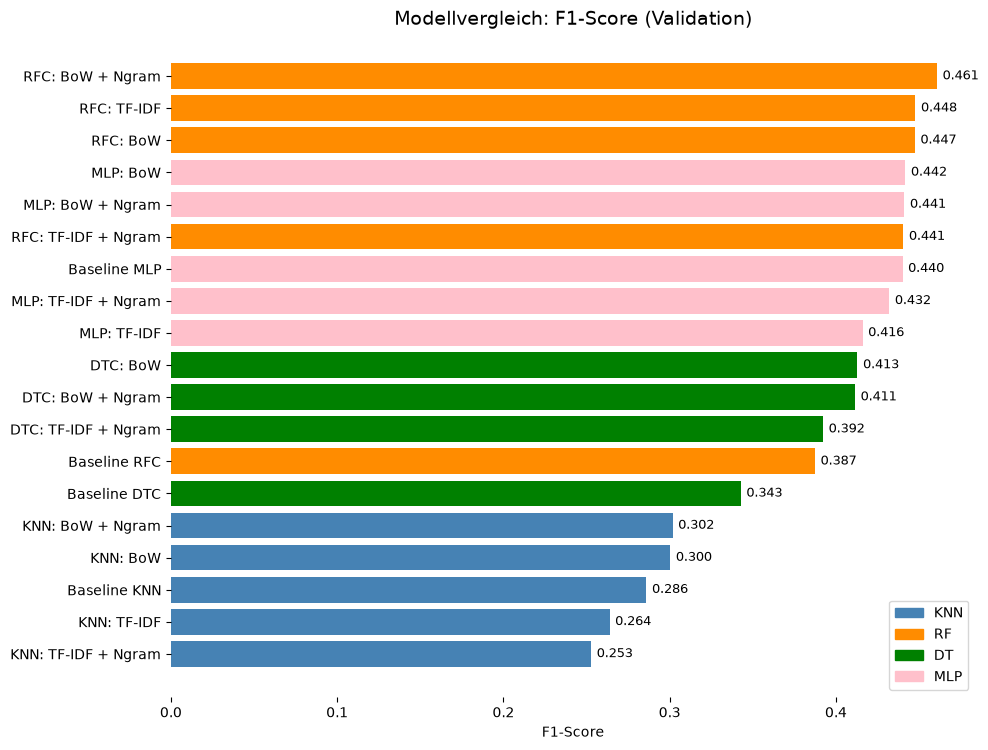

In [231]:
plot_results()

## 7.1.4 Testen des besten Modells

Bestes Modell: RFC: BoW + Ngram
Klassifikationsreport (Zurückgehaltener Testdatensatz):
              precision    recall  f1-score   support

   happiness       0.42      0.44      0.43       544
        love       0.58      0.51      0.54       550
     neutral       0.42      0.47      0.44       601
     sadness       0.46      0.39      0.42       607
       worry       0.29      0.33      0.31       525

    accuracy                           0.43      2827
   macro avg       0.43      0.43      0.43      2827
weighted avg       0.44      0.43      0.43      2827



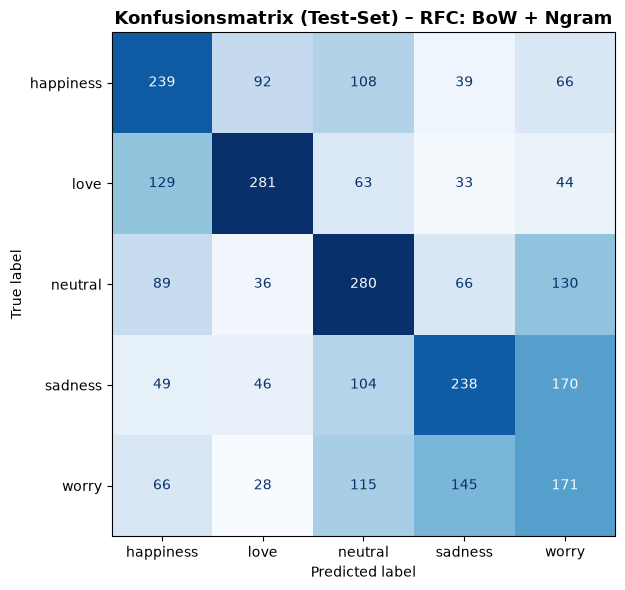

In [232]:
# results[name] = (f1_validation, best_model, X_train, X_val, X_test)

best_name = max(results, key=lambda k: results[k][0])
best_model = results[best_name][1]

# Zurückgehaltenes Testset mit bestem Modell vorhersagen
y_test_pred_best = best_model.predict(results[best_name][4])
labels = sorted(y_test.unique())
matrix = confusion_matrix(y_test, y_test_pred_best)

print(f"Bestes Modell: {best_name}")
print(f"Klassifikationsreport (Zurückgehaltener Testdatensatz):")
print(classification_report(y_test, y_test_pred_best, zero_division=0))

_, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Konfusionsmatrix (Test-Set) – {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Die oben gezeigte Confusion-Matrix visualisiert die Modellgenauigkeit pro Emotionsklasse. Ein Ideales Modell (F1-Score=1) würde alle Werte auf der Diagonalen enthalten. Werte die nicht auf der Diagonalen liegen wurden vom Modell falsch klassifiziert. Erkennbar ist, dass die Emotion `love` am besten erkannt wird und `worry` am schlechtesten. 

Eine mögliche Vermutung für dieses Verhalten ist das, dass sich das Vokabular für `worry` mit `sadness` und `neutral` überschneidet. Erkennbar zudem das unser bestes Modell zuverlässig in der Lage ist positive Emotionen (Hapiness, Love) von negativen Emotionen (Sadness, Worry) zu unterscheiden. Auch neutrale Emotionen werden zuverlässig erkannt. Problematisch und schwierig für das Modell ist die klare unterscheidung zwischen den positiven und negativen Subklassen.

## 7.1.5 Fehleranalyse der Konfusionsmatrix

Die Konfusionsmatrix zeigt neben den korrekten Vorhersagen (Diagonale) auch, **welche Klassen das Modell miteinander verwechselt** (Felder außerhalb der Diagonale). Im Folgenden werden diese Missklassifikationen genauer mit konkreten Beispiel-Tweets untersucht und interpretiert, **warum** sie zustande kommen.

In [233]:
test_df = pd.DataFrame({
    "tweet_original": df.loc[X_test.index, "content"].values,
    "tokens": X_test.values,
    "true_label": y_test.values,
    "pred_label": y_test_pred_best
})

# Sadness → Worry (171 Fälle)
mask = (test_df["true_label"] == "sadness") & (test_df["pred_label"] == "worry")
print("=" * 60)
print("Missklassifikation: Sadness → Worry (Top 10)")
print("=" * 60)
for i, tweet in enumerate(test_df[mask]["tweet_original"].head(10), 1):
    print(f"[{i}] {tweet}")

print()

# Worry → Love (28 Fälle)
mask = (test_df["true_label"] == "worry") & (test_df["pred_label"] == "love")
print("=" * 60)
print("Missklassifikation: Worry → Love (Top 10)")
print("=" * 60)
for i, tweet in enumerate(test_df[mask]["tweet_original"].head(10), 1):
    print(f"[{i}] {tweet}")


Missklassifikation: Sadness → Worry (Top 10)
[1] @tessonfire I feel almost empty inside today.  Not a good feeling.
[2] @3RDegree09 man i still haven't seen that movie...too bad i'm at work
[3] No No No @ankita_gaba will take @Shadez away  Not my day! #shadez #twpp
[4] @cindyefolson the signal that makes your internet &quot;go&quot; is pretty bad  getting a tech out will get that fixed up, though!
[5] @mitchelmusso i can't call you cause my portable sais that this number not excist  i want so much to talk to you
[6] ughhhhhhhh i don't feel good
[7] Don't know if I can watch Holly again, breaks your heart
[8] UGH... I am soooo drag assing today  but on a brighter note I got my G1 update &amp; it is the biznesssss!
[9] I lost 15 dollars. I always lose my money
[10] Yep, @CAndymanTK9772. Sleep-fail. In another 7-8 hours, it'll be D&amp;D-fail.

Missklassifikation: Worry → Love (Top 10)
[1] @anthonyamor hey member when we were better friends then you and anthony. That was pretty sweet ha. 

**Warum kommt es zu diesen Missklassifikationen?**

Die Fehler sind nicht zufällig. Verwechselt werden fast immer Klassen, die sich emotional ähneln:

| Wahr → Vorhergesagt | Anzahl |
|---|---|
| sadness → worry | 170 |
| worry → sadness | 145 |
| love → worry | 44 |
| worry → love | 28 |

Am häufigsten vertauscht das Modell die beiden negativen Klassen `sadness` und `worry` (zusammen 315 mal) und die beiden positiven Klassen `love` und `happiness`. Die Top-10-Beispiele zeigen, warum: Bei **Sadness → Worry** sind Tweets wie „I feel almost empty inside today“ oder „ughhhhhhhh i don't feel good“ sprachlich kaum von Sorgen zu unterscheiden.

Noch deutlicher ist das Problem bei **Worry → Love**: Viele dieser Tweets enthalten schlicht das Wort „love“ – aber in einem anderen Sinn, z. B. „I’d love to go“, „I really love this picture“ oder ein Veranstaltungsort namens „Love“. Das Bag-of-Words-Modell sieht nur das Wort und ordnet den Tweet der Klasse `love` zu, ohne den Kontext zu verstehen.

Für bessere Ergebnisse bräuchte es ein Modell, das den Kontext versteht (z. B. Wort-Embeddings oder Transformer wie bei modernen Sprachmodellen), um „I’d love to go“ von „I love you“ unterscheiden kann.

## 7.1.6 Trainings und Validierungmetriken

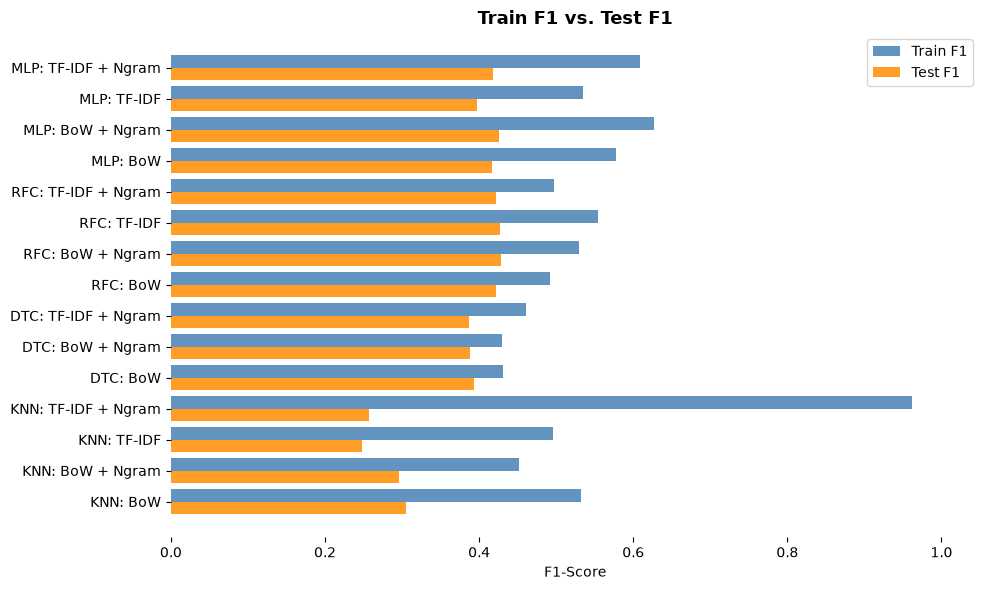

In [234]:
# results[name] = (f1_validation, best_model, X_train, X_val, X_test)

# Baseline-Modelle (Cell 44) nutzen einen anderen Split (y_raw_train) und
# koennen hier nicht mit dem gemeinsamen y_train verglichen werden.

names = [n for n in results if not n.startswith("Baseline")]
f1_train = [f1_score(y_train, results[n][1].predict(results[n][2]), average="macro") for n in names]
f1_test = [f1_score(y_test, results[n][1].predict(results[n][4]), average="macro") for n in names]

_, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(names))

ax.barh(x+0.2, f1_train, 0.4, label="Train F1", color="steelblue", alpha=0.85)
ax.barh(x-0.2, f1_test, 0.4, label="Test F1", color="darkorange", alpha=0.85)
ax.set(yticks=x, yticklabels=names, xlabel="F1-Score", xlim=(0, 1.05))
ax.set_title("Train F1 vs. Test F1", fontsize=13, fontweight="bold")
ax.legend()
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

Die oben gezeigte Grafik stellt für jedes Modell den F1-Score auf den Trainings- und Validierungsdaten gegenüber. Ein großer Abstand zwischen beiden Balken deutet auf Overfitting hin. Das Modell hat die Trainingsdaten dann teilweise auswendig gelernt, statt verallgemeinerbare Muster zu erkennen.

- Beim besten Modell (**Random Forest, BoW + Ngram**) liegt der Train-F1 bei 0,53 und der Validierungs-F1 bei 0,46. Der Abstand ist vorhanden, aber **moderat**. Die Begrenzung über `min_samples_leaf` und `ccp_alpha` hat das Overfitting wirksam eingedämmt.
- Ohne diese Begrenzung war der Effekt deutlich stärker (vgl. der erste ungezähmte Decision Tree bzw. KNN mit k=1 und einem Train-F1 von 0,96 bei gleichzeitig niedrigem Validierungs-F1).
- Ein Rest-Overfitting bleibt bei allen Modellen bestehen. Das ist bei der geringen Datenmenge und der Kürze der Tweets erwartbar und begrenzt die erreichbare Vorhersagequalität.


## 7.2 Fazit und Beantwortung der Forschungsfrage

Zum Abschluss werden die Ergebnisse zusammengeführt und die eingangs gestellte **Forschungsfrage** beantwortet:

> *Lassen sich die in kurzen Tweets ausgedrückten Emotionen mit klassischen Machine-Learning-Verfahren zuverlässig automatisch klassifizieren? Welches Modell liefert die beste Vorhersagequalität?*

### Welches Modell liefert die beste Vorhersagequalität?

Verglichen wurden vier klassische Verfahren (KNN, Decision Tree, Random Forest, MLP) in Kombination mit unterschiedlichen Vektorisierungen (BoW, TF-IDF, jeweils mit und ohne N-gramme). Nach dem Hyperparametertuning ergibt sich auf den folgende Rangfolge:

- **Random Forest (BoW + Ngram): 0,461** (bestes Modell)
- Random Forest (TF-IDF): 0,448
- Random Forest (BoW): 0,447
- MLP (BoW): 0,442
- MLP (BoW + Ngram): 0,441
- KNN und Decision Tree fallen mit Werten um bzw. unter 0,40 klar ab

Das beste Modell ist damit der **Random Forest mit BoW- und N-gram-Vektorisierung** (`n_estimators=80`, `min_samples_leaf=4`, `ccp_alpha=0`). Auf dem **zurückgehaltenen Testset** erreicht es einen F1-Score von **0,43**. Der leichte Rückgang gegenüber der Validierung ist ein normaler Generalisierungseffekt und zeigt, dass das Modell nicht überschätzt wird.

### Lassen sich Emotionen zuverlässig klassifizieren?

Nur **eingeschränkt**. Ein F1-Score von 0,43 über fünf Klassen liegt zwar **deutlich über dem Zufallsniveau** (bei fünf gleich großen Klassen ca. 0,20), aber unter dem in der Literaturrecherche ermittelten Referenzwert von rund **0,55** für stark trainierte Modelle. Dieser Vergleich muss jedoch relativiert werden: Die in der Forschung verwendeten Datensätze sind ein Vielfaches größer als unser auf fünf Klassen reduzierter Korpus. Von einer *zuverlässigen* Klassifikation im engeren Sinne kann daher noch nicht gesprochen werden, wohl aber von einer klar überzufälligen und für erste Anwendungen brauchbaren Erkennung.

### Einschränkungen

- **Datenmenge**: Der bereinigte, auf die Top-5-Emotionen reduzierte Korpus ist für ML-Verhältnisse klein.
- **Klassenausgleich**: Das Undersampling auf gleich große Klassen (n=3.769) vermeidet Verzerrung durch das Ungleichgewicht, verschenkt aber Daten der häufigeren Klassen.
- **Textlänge**: Tweets sind kurz und sprachlich unsauber (Slang, Ironie), was die Klassifikation grundsätzlich erschwert.
- **Methodenklasse**: Bewusst wurden nur klassische ML-Verfahren betrachtet. Die Vektorisierung ignoriert Wortreihenfolge und Kontext weitgehend.

### Ausblick

Die Literaturrecherche zeigt, dass **Deep-Learning-Verfahren** (z. B. BiLSTM mit FastText-Embeddings) und insbesondere **Transformer-Modelle** (BERT o. Ä.) klassische Methoden deutlich übertreffen, weil sie Wortreihenfolge und Kontext berücksichtigen. Ein größerer Datensatz sowie der Einsatz solcher Modelle sind die naheliegendsten Ansätze, um die Vorhersagequalität über die hier erreichten rund 0,43 F1-Score hinaus zu steigern.
